# Walk-forward learning on SP100 daily prices — return/variance features (`Mains.multislice`)

This notebook walks through the **multislice** pipeline using the **`return_variance`** feature set
(`feature_set return_variance` in the parameter file). The network's **decode/prediction target is the
daily return** (`feats[:, 2]`, today/yesterday) and the **secondary encoded channel is a left-sided,
direction-agnostic return variance** (`feats[:, 3]`). This is the sibling of `notebook-multislice_demo.ipynb`,
which instead predicts the trailing-mean price level with a 1st-derivative side channel.
> **Note:** The dataset is whatever `timeseries_file` the parameter file points at (here
> `datasets/sp100_IPO_sorted.csv`, S&P 100 constituents). The notebook reads it once via `DATA_CSV` so the
> displayed prices, the per-ticker features, and `Mains.multislice()` all stay aligned.

In [2]:
#Imports and static variables
import os
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

import Utils
import FeatureGeneration as FG
import RBFBinner
import Mains
import Display


for m in (Utils, FG, Mains, Display):
    importlib.reload(m)
WORKDIR = os.path.dirname(os.path.abspath("Mains.py")) if os.path.exists("Mains.py") else os.getcwd()
os.chdir(WORKDIR)
FIGDIR = "figs/SP100/multislice_return_variance"
os.makedirs(FIGDIR, exist_ok=True)


def figpath(n, stem):
    """Numbered figure path under FIGDIR (``01_…`` through ``99_…``)."""
    return os.path.join(FIGDIR, f"{int(n):02d}_{stem}.png")


def save_fig(fig, n, stem):
    """Save *fig* to FIGDIR with a zero-padded sequence number."""
    path = figpath(n, stem)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return path

# Figure index (all saved under FIGDIR via save_fig / figpath):
#  01 raw_sp100_closes
#  02 rolling_features_<sym>   03 rbf_encoding_<sym>
#  04 return_distribution_raw_vs_log   (reserved — not yet plotted)
#  05 block_coverage_train_val_test
#  06 per_ticker_test_rmse_by_block   07 best_worst_performer_prices
#  08 aggregate_test_error_vs_block   09 test_rmse_heatmap_tickers_blocks
#  10 cross_sectional_mean_test_rmse
#  11–13 block_sweep_*   (reserved — §8b skipped)
#  14 multislice_prediction_<sym>
#  15 ticker_sweep_test_rmse_vs_n_tickers   16 ticker_sweep_rmse_phases   17 ticker_sweep_elapsed_time
#  18 return_transition_<sym>   19 return_persistence_<sym>
#  20 return_transition_all   21 return_persistence_all   22 return_persistence_summary
#  23 ea_trajectory   24 ea_near_optimal_marginals   25 ea_near_optimal_pairs
#  26 ea_cluster_pca   27 ea_cluster_profiles   28 ea_generalisation
#  (§7 param sweeps: unnumbered sweep_*.png under FIGDIR)



PARAMFILE = "Parameters_multislice_return_variance.par"
params = Utils.load_params(PARAMFILE)
if "tickers" in params:
    TICKERS = params["tickers"].split(",")
else:
    TICKERS = FG.csv_ticker_columns(params["timeseries_file"])
TRNPAT = int(params["trnpat"])
VANPAT = int(params["vanpat"])
TENPAT = int(params["tenpat"])
OFFS = int(params["offs"])
WARMUP_PAT = int(params.get("warmup_pat", 0))

# Resolve the active feature set (return_variance). CFG carries the generator
# function, the decode-target column (primary) and the secondary column, plus
# the two bin counts read from the matching *_nbin keys.
CFG = FG.feature_config(PARAMFILE)
PRIMARY_COL = CFG.primary_col        # 2 = daily return (prediction target)
SECONDARY_COL = CFG.secondary_col    # 3 = trailing return variance
RETURN_NBIN = CFG.primary_nbin       # bins for the return channel
VARIANCE_NBIN = CFG.secondary_nbin   # bins for the variance channel
BLOCK_STEP = TRNPAT + VANPAT + TENPAT
W = FG.feature_align(CFG)              # variance_window for return_variance; calendar anchor W-1
VARIANCE_WINDOW = CFG.variance_window  # None for non-return_variance feature sets

# Single source of truth for the dataset: use exactly the CSV the run consumes
# (params["timeseries_file"]) so displayed raw prices, the per-ticker features,
# and Mains.multislice() all stay aligned on the same calendar and ticker set.
DATA_CSV = params["timeseries_file"]

if WARMUP_PAT > 0:
    for name, per_t_len in (("trnpat", TRNPAT), ("vanpat", VANPAT), ("tenpat", TENPAT)):
        if per_t_len <= WARMUP_PAT + OFFS:
            raise ValueError(
                f"{name}={per_t_len} must be > warmup_pat + offs "
                f"({WARMUP_PAT + OFFS}) when warmup is enabled.")

print(f"Working directory: {WORKDIR}")
print(f"Tickers ({len(TICKERS)}): {TICKERS}")
print(f"Per-ticker per-block: trnpat={TRNPAT}  vanpat={VANPAT}  tenpat={TENPAT}  "
      f"warmup_pat={WARMUP_PAT}  block_step={BLOCK_STEP}")
if WARMUP_PAT > 0:
    scored_k1 = TRNPAT - WARMUP_PAT - OFFS
    print(f"  scored steps per segment (k>0): train/val/test = "
          f"{scored_k1}/{VANPAT - WARMUP_PAT - OFFS}/{TENPAT - WARMUP_PAT - OFFS}")


Working directory: /home/fiebig/Dropbox/GIT/BCPNNSim2.2_UC2/tests/UC2-EXTRABRAIN/LTSLtest/financial
Tickers (98): ['AAPL', 'ABT', 'ADBE', 'AIG', 'ALL', 'AMGN', 'AMT', 'AMZN', 'AXP', 'BA', 'BAC', 'BK', 'BKNG', 'BLK', 'BMY', 'C', 'CAT', 'CL', 'CMCSA', 'COF', 'COP', 'COST', 'CSCO', 'CVS', 'CVX', 'DD', 'DHR', 'DIS', 'DUK', 'EMR', 'EXC', 'F', 'FDX', 'GD', 'GE', 'GILD', 'GS', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'JPM', 'KO', 'LIN', 'LLY', 'LMT', 'LOW', 'MCD', 'MDT', 'MMM', 'MO', 'MRK', 'MS', 'MSFT', 'NEE', 'NKE', 'NVDA', 'ORCL', 'PEP', 'PFE', 'PG', 'QCOM', 'RTX', 'SBUX', 'SLB', 'SO', 'SPG', 'T', 'TGT', 'TMO', 'TXN', 'UNH', 'UNP', 'UPS', 'USB', 'VZ', 'WBA', 'WFC', 'WMT', 'XOM', 'MET', 'MDLZ', 'ACN', 'NFLX', 'CRM', 'GOOGL', 'MA', 'PM', 'V', 'AVGO', 'CHTR', 'GM', 'META', 'ABBV', 'KHC', 'PYPL', 'DOW']
Per-ticker per-block: trnpat=500  vanpat=250  tenpat=250  warmup_pat=100  block_step=1000
  scored steps per segment (k>0): train/val/test = 399/149/149


## 1. Raw SP100 close prices

The wide CSV has one row per trading day and one column per ticker. Values are **adjusted close prices**
(already split-adjusted in the source file). Late-IPO names (e.g. META, GOOGL) have leading `NaN`s until their
first quote; `Mains.multislice()` only activates a ticker in blocks where its feature history fully covers
the block window.

In [2]:
csv_path = FG.dataset_path(DATA_CSV)
df_raw = pd.read_csv(csv_path, parse_dates=["Date"])
print(f"Calendar rows: {len(df_raw)}  |  columns (excl. Date): {len(df_raw.columns) - 1}")
print(f"Date range: {df_raw['Date'].iloc[0].date()} → {df_raw['Date'].iloc[-1].date()}")
display(df_raw[TICKERS].describe().T[["count", "min", "max"]].head(10))

Calendar rows: 6324  |  columns (excl. Date): 98
Date range: 2000-01-03 → 2025-02-24


,count,min,max
AAPL,6324.0,0.197414,258.735504
ABT,6324.0,7.013040,134.949997
ADBE,6324.0,8.317788,688.369995
AIG,6324.0,4.493934,1250.231201
ALL,6324.0,9.701691,207.389999
AMGN,6324.0,21.674702,332.021027
AMT,6324.0,0.537356,274.084869
AMZN,6324.0,0.298500,242.059998
AXP,6324.0,8.018998,325.869995
BA,6324.0,16.991482,430.299988


'figs/SP100/multislice_return_variance/01_raw_sp100_closes.png'

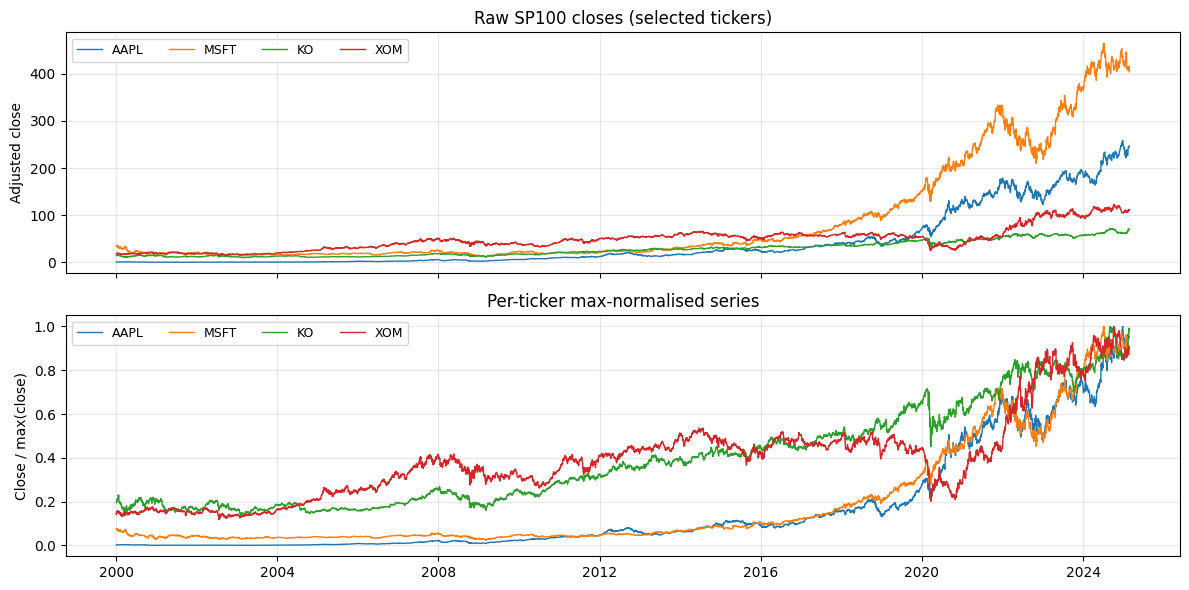

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
sample = ["AAPL", "MSFT", "KO", "XOM"]
for sym in sample:
    axes[0].plot(df_raw["Date"], df_raw[sym], label=sym, lw=1)
axes[0].set_ylabel("Adjusted close")
axes[0].set_title("Raw SP100 closes (selected tickers)")
axes[0].legend(ncol=4, fontsize=9)
axes[0].grid(alpha=0.3)

# Normalised view (per-ticker max scaling — same as FeatureGeneration.load_tickers_features)
for sym in sample:
    s = df_raw[sym].dropna()
    axes[1].plot(s.index.map(lambda i: df_raw.loc[i, "Date"]), s / s.max(), label=sym, lw=1)
axes[1].set_ylabel("Close / max(close)")
axes[1].set_title("Per-ticker max-normalised series")
axes[1].legend(ncol=4, fontsize=9)
axes[1].grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, 1, "raw_sp100_closes")


## 2. Rolling features and RBF encoding

`FeatureGeneration.make_return_variance_features` builds four columns per time step
(after a trailing window of `variance_window` days, default 7 from the parameter file):

| col | meaning | role |
|-----|---------|------|
| 0 | normalised close (value) | unused by the model |
| 1 | simple delta `x[t] − x[t−1]` (no temporal filtering) | unused by the model |
| 2 | **daily return** `x[t] / x[t−1]` | **primary / decode target** |
| 3 | **trailing return variance** (left-sided, direction-agnostic) | **secondary channel** |

The LTSL network predicts column **2** (daily return) at horizon `offs` days ahead.
Inputs are encoded by **two independent 1-D RBF binnings** (return and variance), then combined
via an outer product → `return_nbin × variance_nbin` binary-ish pattern rows written to `features.dat`.

The RBF centre layout follows the `binmode` parameter — `rbf` (linearly spaced centres on a 0.5% winsor range) or `rbf-quantile`
(centres at empirical quantiles with adaptive width). The primary decode-target centres are persisted to a
`features.centers.npy` sidecar so decode/plotting uses the exact centres that were encoded.

'figs/SP100/multislice_return_variance/02_rolling_features_AMZN.png'

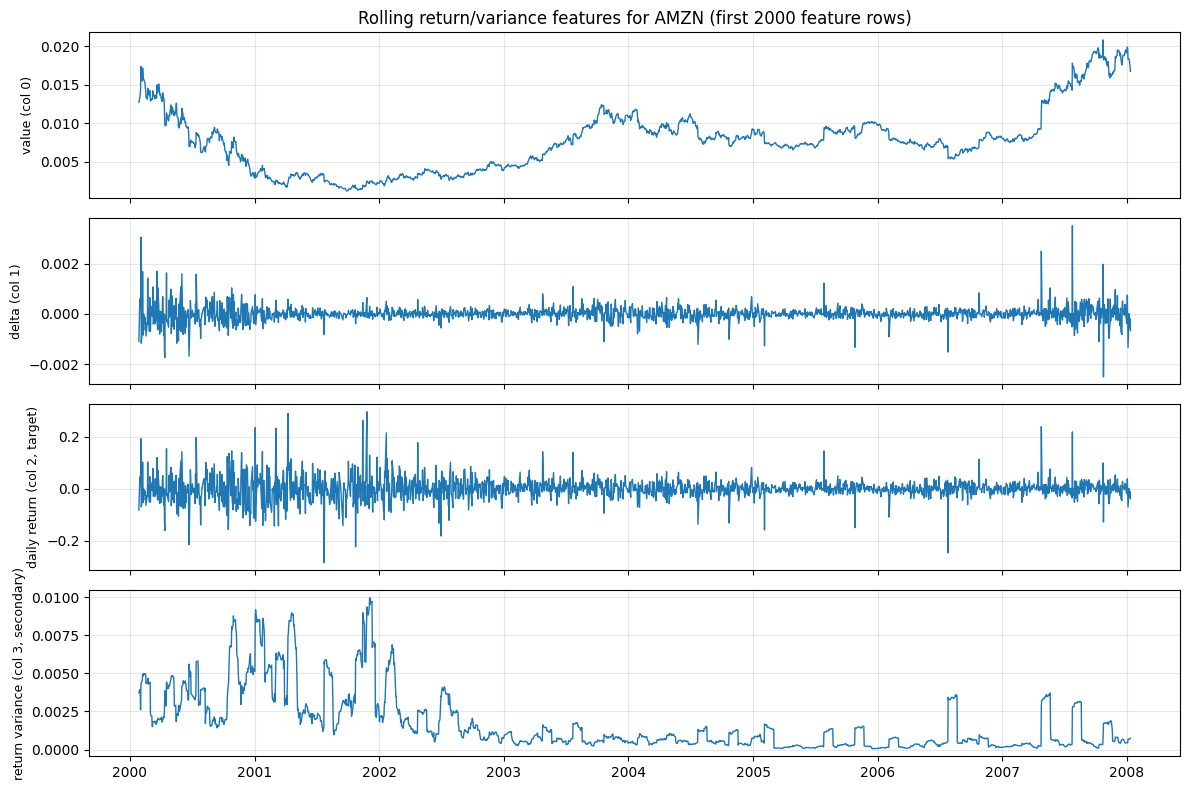

In [4]:
# Use the active feature set (CFG.func -> make_return_variance_features) so the
# per-ticker features here are exactly what Mains.multislice() will encode/run.
per_ticker, csv_lens = FG.load_tickers_features(
    DATA_CSV, ",".join(TICKERS), feature_func=CFG.func, feature_align=W)
demo_sym = "AMZN"
feats = per_ticker[demo_sym]["feats"]
n_show = 2000
t_axis = df_raw["Date"].iloc[per_ticker[demo_sym]["first_valid_feat_row"]:][:n_show]

fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
labels = ["value (col 0)", "delta (col 1)",
          "daily return (col 2, target)", "return variance (col 3, secondary)"]
for k, ax in enumerate(axs):
    ax.plot(t_axis, feats[:n_show, k], lw=1)
    ax.set_ylabel(labels[k], fontsize=9)
    ax.grid(alpha=0.3)
axs[0].set_title(f"Rolling return/variance features for {demo_sym} (first {n_show} feature rows)")
plt.tight_layout()
save_fig(fig, 2, f"rolling_features_{demo_sym}")


Return decode max |error|: 0.1418


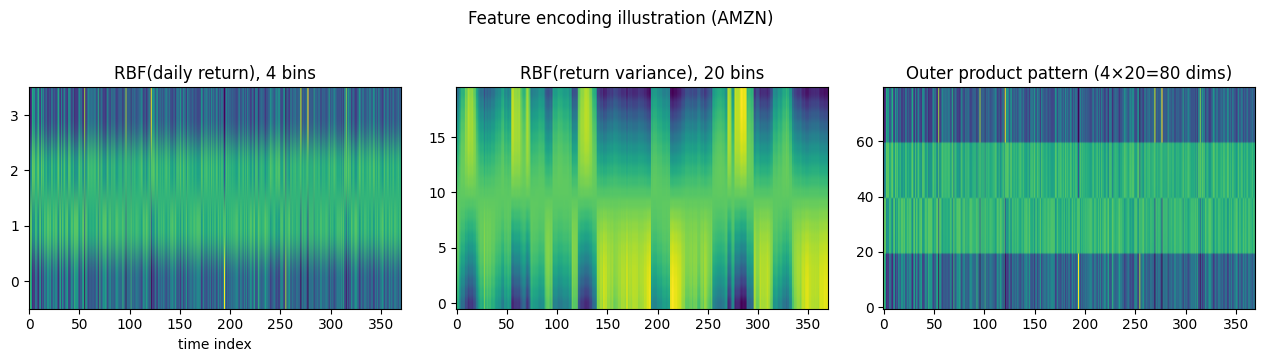

In [5]:
# RBF encoding on a short slice (multislice uses the pooled stream via build_patterns).
# Primary channel = daily return (col 2, decode target); secondary = variance (col 3).
slice_feats = feats[180:550]
enc_return = FG._make_channel_encoder(slice_feats[:, PRIMARY_COL], RETURN_NBIN, CFG.binmode)
enc_var = FG._make_channel_encoder(slice_feats[:, SECONDARY_COL], VARIANCE_NBIN, CFG.binmode)
p_return = enc_return.encode(slice_feats[:, PRIMARY_COL])
p_var = enc_var.encode(slice_feats[:, SECONDARY_COL])
# Primary is the OUTER factor (matches FeatureGeneration.build_patterns / the C++ marginal).
patterns = (p_return[:, :, None] * p_var[:, None, :]).reshape(len(slice_feats), -1)

fig, axs = plt.subplots(1, 3, figsize=(13, 3.5))
axs[0].imshow(p_return[:].T, aspect="auto", origin="lower", cmap="viridis")
axs[0].set_title(f"RBF(daily return), {RETURN_NBIN} bins")
axs[0].set_xlabel("time index")
axs[1].imshow(p_var[:].T, aspect="auto", origin="lower", cmap="viridis")
axs[1].set_title(f"RBF(return variance), {VARIANCE_NBIN} bins")
axs[2].imshow(patterns[:].T, aspect="auto", origin="lower", cmap="viridis")
axs[2].set_title(f"Outer product pattern ({RETURN_NBIN}×{VARIANCE_NBIN}={patterns.shape[1]} dims)")
plt.suptitle(f"Feature encoding illustration ({demo_sym})", y=1.02)
plt.tight_layout()
save_fig(fig, 3, f"rbf_encoding_{demo_sym}")

# Decode round-trip on the return (target) channel
recon = enc_return.decode(p_return)
print(f"Return decode max |error|: {np.max(np.abs(recon - slice_feats[:, PRIMARY_COL])):.4g}")


## 3. Block-wise walk-forward schedule

Instead of holding out entire tickers for testing (which leaks calendar structure), **multislice** cuts
the shared timeline into consecutive blocks. Block `b` spans feature rows
`[calendar_start + b·block_step, …)` with `calendar_start = W−1`.

Within each block, patterns are concatenated in order:

`[train_t0, train_t1, …, val_t0, …, test_t0, …]`

The C++ simulator reads one row per block from `schedule.dat` (`trnpat vanpat tenpat` **totals** for that
block, summed over active tickers). Network state (weights + LTSL memory) **carries across blocks** — this
is continual learning on a single long run.

**Warmup (`warmup_pat`, default 50):** at each ticker-to-ticker cut within a phase (`k > 0`), the first
`warmup_pat` patterns are replayed forward-only (LTSL adapts, weights frozen, outputs not logged). RMSE is
computed only on the remaining suffix of each segment. The first ticker in each phase (`k = 0`) is scored
over the full window. Warmup does **not** add calendar rows or change `block_step`; it replays within each
ticker's `trnpat` / `vanpat` / `tenpat` budget. Require each phase length to be **> `warmup_pat + offs`**; set
`warmup_pat 0` to disable.

Candidate blocks (longest history): 6


'figs/SP100/multislice_return_variance/05_block_coverage_train_val_test.png'

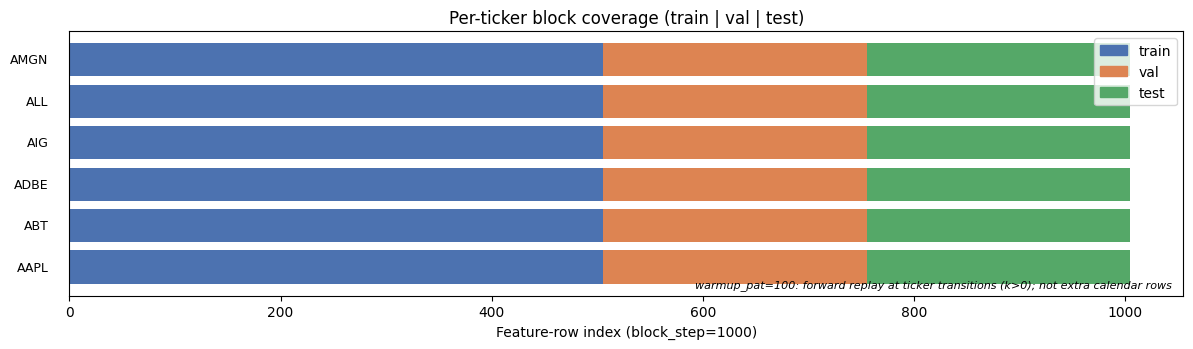

In [6]:
calendar_start = W - 1
max_end = max(d["first_valid_feat_row"] + d["feats"].shape[0] for d in per_ticker.values())
n_blocks = (max_end - calendar_start) // BLOCK_STEP
print(f"Candidate blocks (longest history): {n_blocks}")

# Calendar coverage: train | val | test per block (warmup replays within per_t_len — no extra rows)
phase_colors = {"train": "#4C72B0", "val": "#DD8452", "test": "#55A868"}
fig, ax = plt.subplots(figsize=(12, 0.35 * len(TICKERS[:6]) + 1.5))

for row, sym in enumerate(TICKERS[:6]):
    d = per_ticker[sym]
    fv = d["first_valid_feat_row"]
    n_feat = d["feats"].shape[0]
    for b in range(n_blocks):
        b_start = calendar_start + b * BLOCK_STEP
        sl = b_start - fv
        if sl < 0 or sl + BLOCK_STEP > n_feat:
            continue
        x0 = b
        phase_x = x0
        ax.barh(row, TRNPAT, left=phase_x, color=phase_colors["train"], height=0.8)
        phase_x += TRNPAT
        ax.barh(row, VANPAT, left=phase_x, color=phase_colors["val"], height=0.8)
        phase_x += VANPAT
        ax.barh(row, TENPAT, left=phase_x, color=phase_colors["test"], height=0.8)
    ax.text(-0.02 * BLOCK_STEP, row, sym, ha="right", va="center", fontsize=9)

ax.set_xlabel(f"Feature-row index (block_step={BLOCK_STEP})")
ax.set_yticks([])
ax.set_title("Per-ticker block coverage (train | val | test)")
legend_handles = [Patch(color=c, label=k) for k, c in phase_colors.items()]
ax.legend(handles=legend_handles, loc="upper right")
if WARMUP_PAT > 0:
    ax.text(
        0.99, 0.02,
        f"warmup_pat={WARMUP_PAT}: forward replay at ticker transitions (k>0); not extra calendar rows",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8, style="italic")
plt.tight_layout()
save_fig(fig, 5, "block_coverage_train_val_test")


In [7]:
# Map block indices to calendar dates (using AAPL as reference timeline)
ref = per_ticker["AAPL"]
ref_dates = df_raw["Date"].iloc[ref["first_valid_feat_row"]: ref["first_valid_feat_row"] + ref["feats"].shape[0]]

block_table = []
for b in range(n_blocks):
    sl = calendar_start + b * BLOCK_STEP - ref["first_valid_feat_row"]
    active = [sym for sym in TICKERS
              if 0 <= (calendar_start + b * BLOCK_STEP - per_ticker[sym]["first_valid_feat_row"])
              and (calendar_start + b * BLOCK_STEP - per_ticker[sym]["first_valid_feat_row"] + BLOCK_STEP)
              <= per_ticker[sym]["feats"].shape[0]]
    block_table.append({
        "block": b,
        "train_start": ref_dates.iloc[sl].date() if 0 <= sl < len(ref_dates) else None,
        "test_end": ref_dates.iloc[min(sl + BLOCK_STEP - 1, len(ref_dates)-1)].date() if sl >= 0 else None,
        "n_active_tickers": len(active),
        "schedule_trn": len(active) * TRNPAT,
        "schedule_ten": len(active) * TENPAT,
    })
pd.DataFrame(block_table)

,block,train_start,test_end,n_active_tickers,schedule_trn,schedule_ten
0,0,2000-01-28,2004-01-22,81,40500,20250
1,1,2004-01-23,2008-01-11,85,42500,21250
2,2,2008-01-14,2011-12-29,88,44000,22000
3,3,2011-12-30,2015-12-21,93,46500,23250
4,4,2015-12-22,2019-12-11,97,48500,24250
5,5,2019-12-12,2023-12-01,98,49000,24500


## 4. Run Mains.multislice() on the complete ticker list
This invokes ./ltslmain once with the full multi-block schedule. 

In [8]:
#Comment out to skip re-running ltslmain (takes ~21 minutes)
result = Mains.multislice(PARAMFILE, exefile="./ltslmain", verbose=True)

Mains.multislice: timeseries_file=sp100_IPO_sorted.csv
  tickers=['AAPL', 'ABT', 'ADBE', 'AIG', 'ALL', 'AMGN', 'AMT', 'AMZN', 'AXP', 'BA', 'BAC', 'BK', 'BKNG', 'BLK', 'BMY', 'C', 'CAT', 'CL', 'CMCSA', 'COF', 'COP', 'COST', 'CSCO', 'CVS', 'CVX', 'DD', 'DHR', 'DIS', 'DUK', 'EMR', 'EXC', 'F', 'FDX', 'GD', 'GE', 'GILD', 'GS', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'JPM', 'KO', 'LIN', 'LLY', 'LMT', 'LOW', 'MCD', 'MDT', 'MMM', 'MO', 'MRK', 'MS', 'MSFT', 'NEE', 'NKE', 'NVDA', 'ORCL', 'PEP', 'PFE', 'PG', 'QCOM', 'RTX', 'SBUX', 'SLB', 'SO', 'SPG', 'T', 'TGT', 'TMO', 'TXN', 'UNH', 'UNP', 'UPS', 'USB', 'VZ', 'WBA', 'WFC', 'WMT', 'XOM', 'MET', 'MDLZ', 'ACN', 'NFLX', 'CRM', 'GOOGL', 'MA', 'PM', 'V', 'AVGO', 'CHTR', 'GM', 'META', 'ABBV', 'KHC', 'PYPL', 'DOW']
  trnpat=500  vanpat=250  tenpat=250  warmup_pat=100  block_step=1000
  calendar_start=18  max_calendar_end=6324  candidate blocks=6
  n_blocks=6  total feature rows=542000  (per-phase totals: trn=271000, van=135500, ten=135500)


Hj = 1 nactHi = 14 nsilHi = 0 denHi = 14 Mi = 80 denNi = 1120


paramfile = Parameters_multislice_return_variance.par
schedule_file = schedule.dat  (6 blocks; sum trn=271000 van=135500 ten=135500)
warmup_pat = 100  (forward-only at ticker transitions k>0)
taup = 271.000
eps = 3.7e-06
K_mode = linear
BLOCK 1/6  trnpat=40500 vanpat=20250 tenpat=20250  (simstep=0)
BLOCK 2/6  trnpat=42500 vanpat=21250 tenpat=21250  (simstep=121176)
BLOCK 3/6  trnpat=44000 vanpat=22000 tenpat=22000  (simstep=248336)
BLOCK 4/6  trnpat=46500 vanpat=23250 tenpat=23250  (simstep=379984)
BLOCK 5/6  trnpat=48500 vanpat=24250 tenpat=24250  (simstep=519112)
BLOCK 6/6  trnpat=49000 vanpat=24500 tenpat=24500  (simstep=664224)
Total simsteps = 810832, time elapsed = 213.262 sec
  train: mean RMSE = 0.019525  persistence = 0.027976  (542/588 valid entries)
  val  : mean RMSE = 0.017703  persistence = 0.025094  (542/588 valid entries)
  test : mean RMSE = 0.016501  persistence = 0.023639  (542/588 valid entries)


In [9]:
rmse = result["rmse"]          # [n_tickers, 3 phases, n_blocks]
valid = result["valid"]
pers = result["persistence"]
labels = result["tickers"]
n_blocks_run = result["n_blocks"]
phase_names = ["train", "val", "test"]

print(f"RMSE cube shape: {rmse.shape}  (tickers × phases × blocks)")
print(f"Blocks executed: {n_blocks_run}")
print(f"warmup_pat: {result.get('warmup_pat', 0)}")

# Show schedule sidecar written for ltslmain
with open(params["schedule_file"]) as fp:
    sched_lines = fp.read().strip().splitlines()
print(f"\n{params['schedule_file']} ({len(sched_lines)} rows):")
for i, line in enumerate(sched_lines):
    print(f"  block {i}: {line}")

RMSE cube shape: (98, 3, 6)  (tickers × phases × blocks)
Blocks executed: 6
warmup_pat: 100

schedule.dat (6 rows):
  block 0: 40500 20250 20250
  block 1: 42500 21250 21250
  block 2: 44000 22000 22000
  block 3: 46500 23250 23250
  block 4: 48500 24250 24250
  block 5: 49000 24500 24500


## 5. Test error vs. prior learning (block index)

Block index doubles as **how much calendar history the network has already trained on** (cumulative
continual learning). We expect early blocks to behave differently from later ones — especially around
regime changes (e.g. 2008–2009 for cyclical names).

'figs/SP100/multislice_return_variance/06_per_ticker_test_rmse_by_block.png'

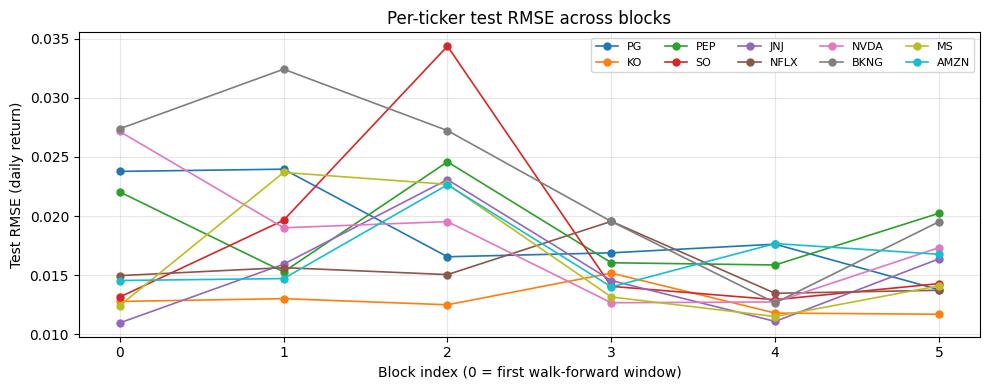

In [10]:
test_rmse = rmse[:, 2, :]   # phase index 2 = test
test_valid = valid[:, 2, :]
prior_train_days = np.arange(n_blocks_run) * BLOCK_STEP  # feature rows seen before each block

# Calendar year at test-phase start (AAPL reference timeline) for x-axis labels on figs 8–9
_ref = per_ticker["AAPL"]
_ref_dates = df_raw["Date"].iloc[
    _ref["first_valid_feat_row"] : _ref["first_valid_feat_row"] + _ref["feats"].shape[0]
]
block_year_labels = []
for b in range(n_blocks_run):
    test_start = calendar_start + b * BLOCK_STEP + TRNPAT + VANPAT - _ref["first_valid_feat_row"]
    if 0 <= test_start < len(_ref_dates):
        block_year_labels.append(str(_ref_dates.iloc[test_start].year))
    else:
        block_year_labels.append(str(b))

stockperformance = np.nanmean(test_rmse, axis=1)
# Next Find indices of 5 best and worst performers
bottom5_idx = np.argsort(stockperformance)[-5:][::-1]
top5_idx = np.argsort(stockperformance)[:5]
bottom5_labels = [labels[i] for i in bottom5_idx]
top5_labels = [labels[i] for i in top5_idx]


fig, ax = plt.subplots(figsize=(10, 4))
for i, sym in enumerate(top5_labels+bottom5_labels): #here I wanna pick the 5 best and 5 worst performers to plot out
    v = test_valid[i]
    ax.plot(np.where(v)[0], test_rmse[i, v], "o-", ms=5, lw=1.2, label=sym)
ax.set_xlabel("Block index (0 = first walk-forward window)")
ax.set_ylabel("Test RMSE (daily return)")
ax.set_title("Per-ticker test RMSE across blocks")
ax.legend(ncol=5, fontsize=8, loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, 6, "per_ticker_test_rmse_by_block")

'figs/SP100/multislice_return_variance/07_best_worst_performer_prices.png'

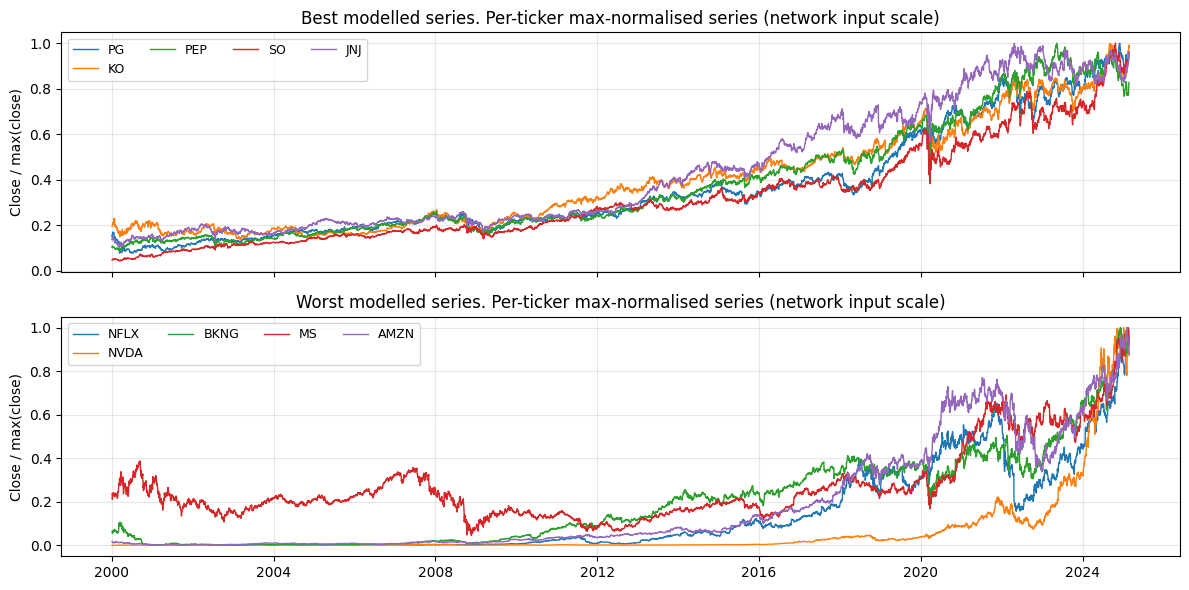

In [11]:
#OK, what is goin on with the best and the worst performers?

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for sym in top5_labels:
    s = df_raw[sym].dropna()
    axes[0].plot(s.index.map(lambda i: df_raw.loc[i, "Date"]), s / s.max(), label=sym, lw=1)
axes[0].set_ylabel("Close / max(close)")
axes[0].set_title("Best modelled series. Per-ticker max-normalised series (network input scale)")
axes[0].legend(ncol=4, fontsize=9)
axes[0].grid(alpha=0.3)

for sym in bottom5_labels:
    s = df_raw[sym].dropna()
    axes[1].plot(s.index.map(lambda i: df_raw.loc[i, "Date"]), s / s.max(), label=sym, lw=1)
axes[1].set_ylabel("Close / max(close)")
axes[1].set_title("Worst modelled series. Per-ticker max-normalised series (network input scale)")
axes[1].legend(ncol=4, fontsize=9)
axes[1].grid(alpha=0.3)
plt.tight_layout()

save_fig(fig, 7, "best_worst_performer_prices")

'figs/SP100/multislice_return_variance/08_aggregate_test_error_vs_block.png'

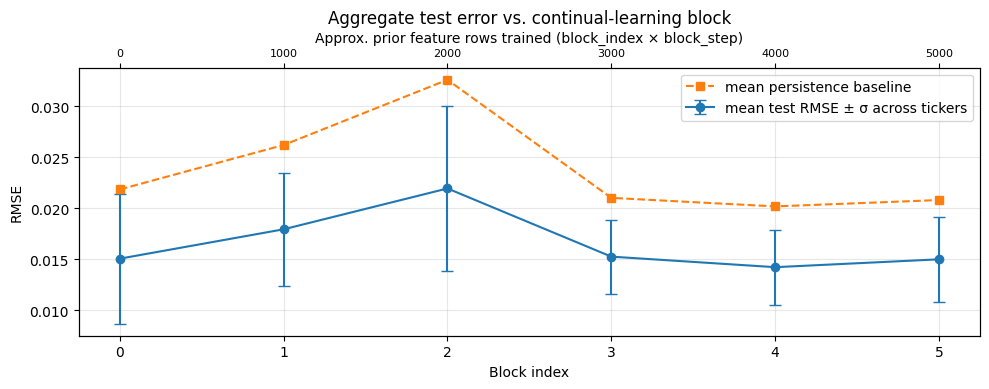

In [12]:
mean_by_block = np.nanmean(test_rmse, axis=0)
std_by_block = np.nanstd(test_rmse, axis=0)
pers_mean = np.nanmean(pers[:, 2, :], axis=0)

fig, ax1 = plt.subplots(figsize=(10, 4))
x = np.arange(n_blocks_run)
ax1.errorbar(x, mean_by_block, yerr=std_by_block, fmt="o-", capsize=4, color="C0", label="mean test RMSE ± σ across tickers")
ax1.plot(x, pers_mean, "s--", color="C1", label="mean persistence baseline")
ax1.set_xticks(x)
ax1.set_xticklabels(block_year_labels)
ax1.set_xlabel("Year (test phase start, AAPL calendar)")
ax1.set_ylabel("RMSE")
ax1.set_title("Aggregate test error vs. continual-learning block")
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(x)
ax2.set_xticklabels([f"{int(d)}" for d in prior_train_days], fontsize=8)
ax2.set_xlabel("Approx. prior feature rows trained (block_index × block_step)")
plt.tight_layout()
save_fig(fig, 8, "aggregate_test_error_vs_block")


'figs/SP100/multislice_return_variance/09_test_rmse_heatmap_tickers_blocks.png'

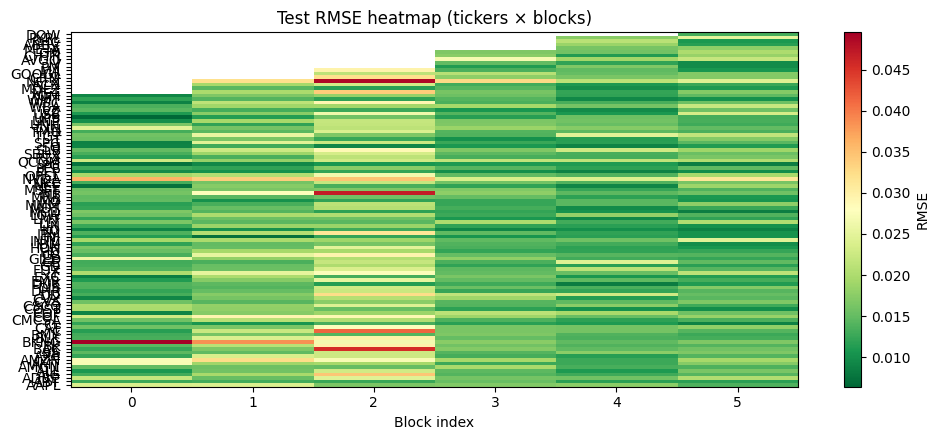

In [13]:
fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(test_rmse, aspect="auto", cmap="RdYlGn_r", origin="lower")  # green to red (reversed)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xticks(range(n_blocks_run))
ax.set_xticklabels(block_year_labels, rotation=45, ha="right")
ax.set_xlabel("Year (test phase start, AAPL calendar)")
ax.set_title("Test RMSE heatmap (tickers × blocks)")
plt.colorbar(im, ax=ax, label="RMSE")
plt.tight_layout()
save_fig(fig, 9, "test_rmse_heatmap_tickers_blocks")

## 6. Cross-stock comparison on the ticker sample

Summarise **mean test RMSE over all blocks** and check dispersion. Consumer staples (KO, PG) often show
lower error than volatile tech / industrial names; crisis-era blocks inflate error for cyclicals.

,ticker,mean_test_rmse,std_test_rmse,max_test_rmse,mean_persistence,beats_persistence
61,PG,0.0097,0.0013,0.0110,0.0140,1.0
43,KO,0.0100,0.0014,0.0128,0.0147,1.0
59,PEP,0.0101,0.0011,0.0123,0.0148,1.0
66,SO,0.0104,0.0014,0.0129,0.0150,1.0
41,JNJ,0.0106,0.0016,0.0122,0.0152,1.0
...,...,...,...,...,...,...
7,AMZN,0.0231,0.0065,0.0324,0.0329,1.0
53,MS,0.0231,0.0115,0.0470,0.0333,1.0
12,BKNG,0.0273,0.0128,0.0495,0.0387,1.0
57,NVDA,0.0306,0.0049,0.0360,0.0434,1.0


'figs/SP100/multislice_return_variance/10_cross_sectional_mean_test_rmse.png'

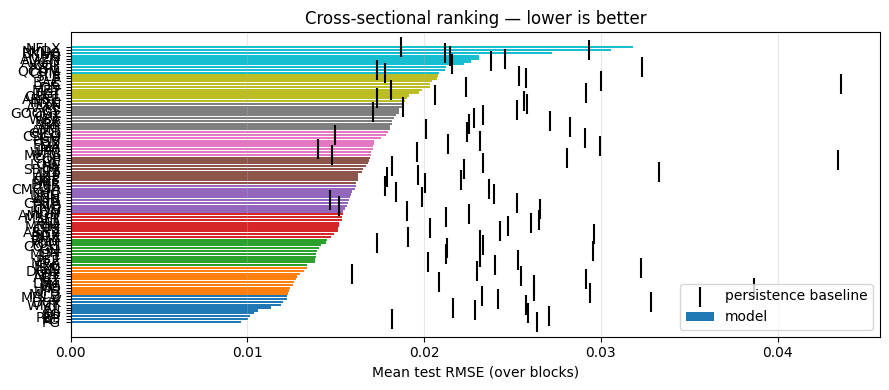

In [14]:
summary_rows = []
for i, sym in enumerate(labels):
    m = test_valid[i]
    summary_rows.append({
        "ticker": sym,
        "mean_test_rmse": float(np.nanmean(test_rmse[i, m])),
        "std_test_rmse": float(np.nanstd(test_rmse[i, m])),
        "max_test_rmse": float(np.nanmax(test_rmse[i, m])),
        "mean_persistence": float(np.nanmean(pers[i, 2, m])),
        "beats_persistence": float(np.nanmean(test_rmse[i, m] < pers[i, 2, m])),
    })
summary = pd.DataFrame(summary_rows).sort_values("mean_test_rmse")
display(summary.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
colors = plt.cm.tab10(np.linspace(0, 1, len(summary)))
ax.barh(summary["ticker"], summary["mean_test_rmse"], color=colors, label="model")
ax.scatter(summary["mean_persistence"], summary.index, marker="|", s=200, c="k", zorder=3, label="persistence baseline")
ax.set_xlabel("Mean test RMSE (over blocks)")
ax.set_title("Cross-sectional ranking — lower is better")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
save_fig(fig, 10, "cross_sectional_mean_test_rmse")


In [15]:
# Where does each ticker hurt most? (block of max test RMSE)
worst = []
for i, sym in enumerate(labels):
    m = test_valid[i]
    blocks = np.where(m)[0]
    vals = test_rmse[i, m]
    j = np.argmax(vals)
    b = blocks[j]
    sl = calendar_start + b * BLOCK_STEP - per_ticker[sym]["first_valid_feat_row"]
    d0 = ref_dates.iloc[sl].date() if 0 <= sl < len(ref_dates) else "?"
    worst.append({"ticker": sym, "worst_block": int(b), "test_rmse": float(vals[j]), "period_start": d0})
pd.DataFrame(worst).sort_values("test_rmse", ascending=False)

,ticker,worst_block,test_rmse,period_start
12,BKNG,0,0.049524,2000-01-28
84,NFLX,2,0.048599,2005-08-26
53,MS,2,0.046990,2008-01-14
10,BAC,2,0.045437,2008-01-14
15,C,2,0.041607,2008-01-14
...,...,...,...,...
66,SO,1,0.012851,2004-01-23
43,KO,2,0.012818,2008-01-14
59,PEP,2,0.012257,2008-01-14
41,JNJ,2,0.012227,2008-01-14


## 6b. Test prediction and uncertainty (BA)

After a multislice run, model outputs live in the concatenated ``netw1_outpop_*_dist.bin`` streams — one logged row per scored step, in block / phase / ticker order (warmup replay steps are omitted). ``Display.stitch_multislice_ticker`` inverts that layout for a single symbol; ``Display.plot_multislice_prediction(..., phases="test")`` returns ``(fig, ax, rmses)`` so the plot can be adjusted in the notebook before saving; it draws only the **unseen/test** decoded **daily return** (the primary channel) with central credible bands (same convention as ``plot_general_prediction``).


BA: 894 test steps across 6 blocks
RMSE test = 0.01698  persistence = 0.02992


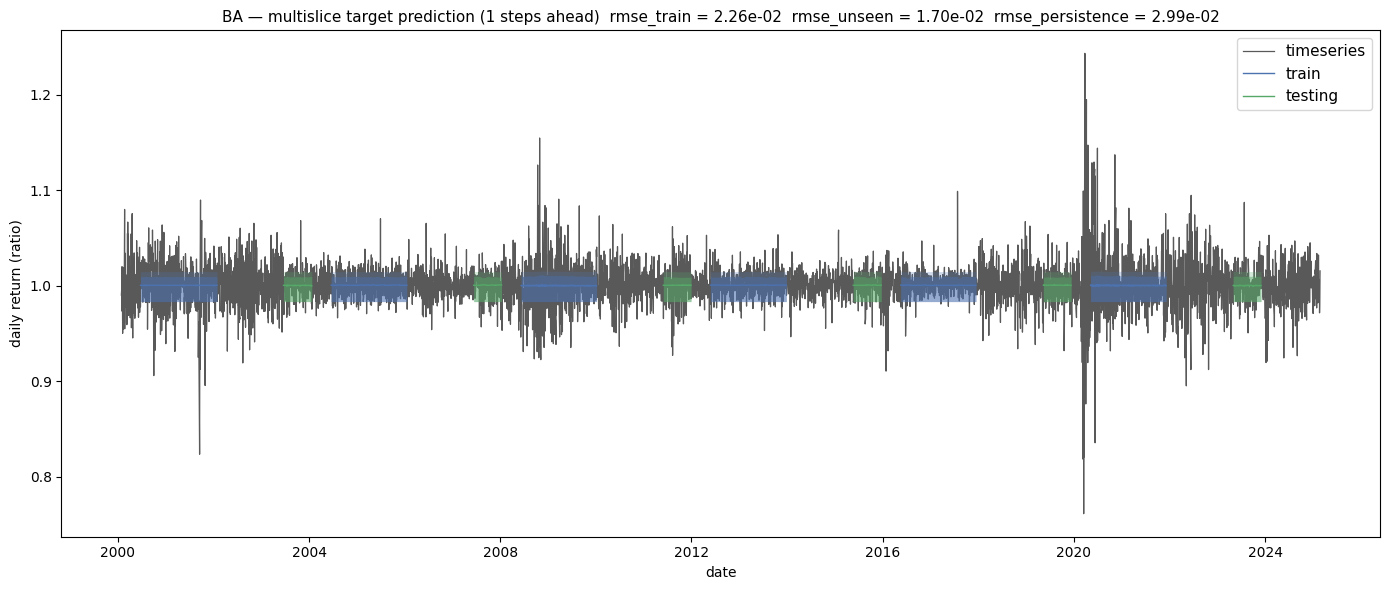

In [16]:
# Stitched walk-forward test predictions + uncertainty bands
for m in (Utils, FG, Mains, Display):
    importlib.reload(m)

sym = "BA"
sym_dates = df_raw["Date"].iloc[
    per_ticker[sym]["first_valid_feat_row"]:
    per_ticker[sym]["first_valid_feat_row"] + per_ticker[sym]["feats"].shape[0]
]

series_sym = Display.stitch_multislice_ticker(PARAMFILE, sym)
test_pts = int((series_sym["phase"] == 2).sum())
print(f"{sym}: {test_pts} test steps across "
      f"{series_sym['block'].max() + 1} blocks")

fig, ax, rmse_sym = Display.plot_multislice_prediction(
    PARAMFILE,
    sym,
    phases=["test", "train"],
    confidence_levels=(0.7, 0.9),
    dates=sym_dates.values,
    series=series_sym,
)

# Adjust figure in-place before saving (examples):
# ax.set_xlim(sym_dates.iloc[-800], sym_dates.iloc[-1])
# ax.set_title(f"{sym} — walk-forward test predictions")

fig.tight_layout()
#ax.set_xlim(18100,19600)
save_fig(fig, 14, f"multislice_prediction_{sym}")
print(f"RMSE test = {rmse_sym[2]:.4g}  persistence = {rmse_sym[3]:.4g}")

## 7. Picking the right parameters

Dedicated 1-D sweeps over `K`, `K_mode`, `taumax`, `return_nbin`, `variance_nbin`, `variance_window`, and
`binmode` (via `Parameters_multislice_return_variance_work.par` so the baseline `.par` is never clobbered).


Parameter sweep: 2 combinations to run
  [1/2] {'binmode': 'rbf'} -> rmse_unseen = 1.2410e-01  (213.4s, ~3m33s left)
  [2/2] {'binmode': 'rbf-quantile'} -> rmse_unseen = 1.6501e-02  (214.2s, ~0m00s left)
  Saved: figs/SP100/multislice_return_variance/sweep_binmode.png
Parameter sweep: 5 combinations to run
  [1/5] {'taumax': 100} -> rmse_unseen = 1.6502e-02  (213.8s, ~14m15s left)
  [2/5] {'taumax': 500} -> rmse_unseen = 1.6501e-02  (214.0s, ~10m41s left)
  [3/5] {'taumax': 1000} -> rmse_unseen = 1.6501e-02  (212.2s, ~7m06s left)
  [4/5] {'taumax': 1500} -> rmse_unseen = 1.6501e-02  (214.5s, ~3m33s left)
  [5/5] {'taumax': 2000} -> rmse_unseen = 1.6501e-02  (211.4s, ~0m00s left)
  Saved: figs/SP100/multislice_return_variance/sweep_taumax.png
Parameter sweep: 6 combinations to run
  [1/6] {'return_nbin': 2} -> rmse_unseen = 1.6501e-02  (144.7s, ~12m03s left)
  [2/6] {'return_nbin': 3} -> rmse_unseen = 1.6500e-02  (156.1s, ~10m01s left)
  [3/6] {'return_nbin': 4} -> rmse_unseen = 1.6501e

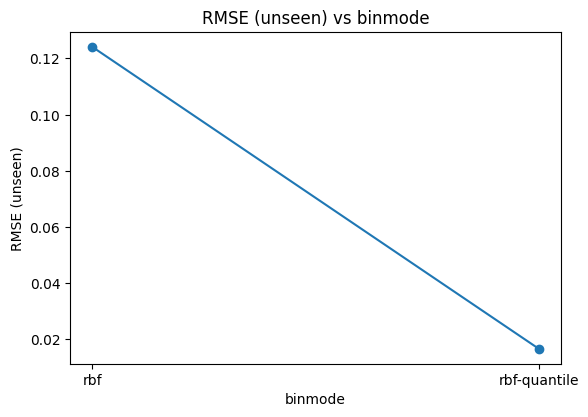

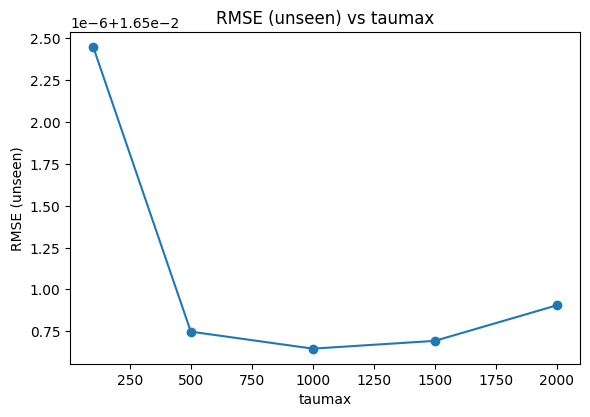

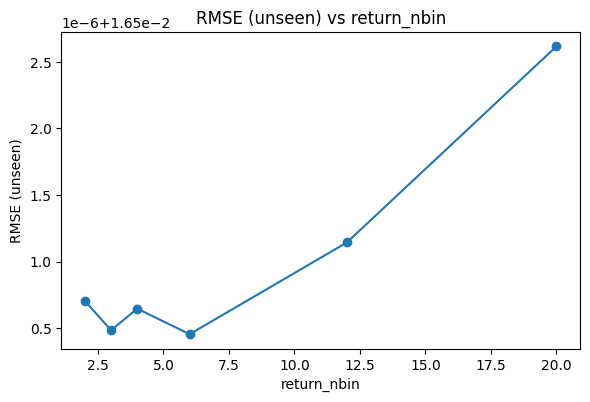

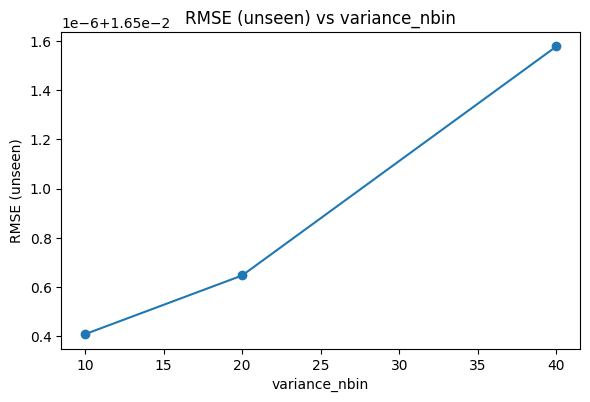

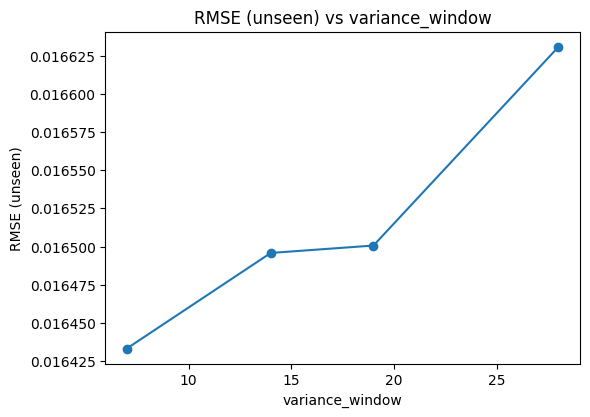

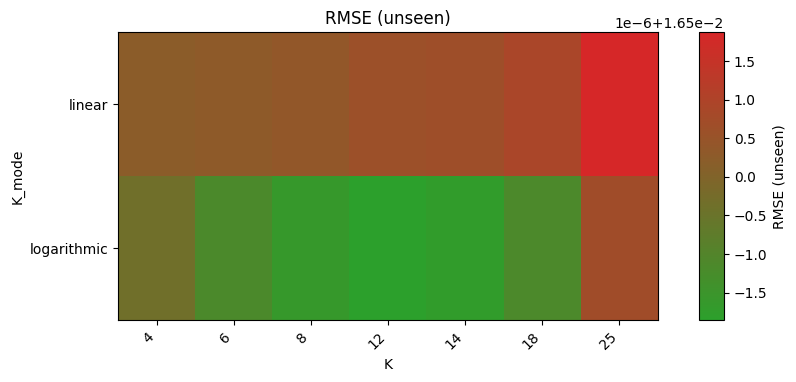

In [18]:
# Dedicated work .par for the sweeps so we never clobber Parameters.par. param_sweep
# writes the (cloned + overridden) config here, and Utils.multislice_for_sweep forwards
# the same path to Mains.multislice via run_kwargs["paramfile"]. feature_set=return_variance
# is inherited from default_paramfile=PARAMFILE, so return_nbin/variance_nbin are the
# bins that actually take effect.
# Outcome metric: metric="rmse_unseen" (default) or any of quadratic_loss / smooth_loss /
# tick_loss / firm_loss / rmse_train / rmse_validation / rmse_persistence.
SWEEP_WORK_PAR = "Parameters_multislice_return_variance_work.par"
SWEEP_RUN_KWARGS = {
    "paramfile": SWEEP_WORK_PAR,
    "figno": 0,
    "verbose": False,
    "var_level": 0.95,
}

#Define a Sweep
sweep_spec = { # --- Define parameter values to sweep  ---
    "binmode":       ["rbf", "rbf-quantile"] #"rbf", "rbf-quantile" free choice of rbf or rbf-quantile mode 
    }
#Run the Sweep
results = Utils.param_sweep(
    sweep_spec,
    default_paramfile=PARAMFILE,       # return_variance multislice baseline
    paramfile=SWEEP_WORK_PAR,          # dedicated work file
    run_fn=Utils.multislice_for_sweep,
    run_kwargs=SWEEP_RUN_KWARGS,
    metric="rmse_unseen",  # or tick_loss, firm_loss, ...
)
#Plot the Sweep
Display.plot_sweep_heatmaps(results, sweep_spec, savepath=FIGDIR + "/")


#Define a Sweep
sweep_spec = { # --- Define parameter values to sweep  ---
    "taumax":        [100,500,1000,1500,2000] 
    }
#Run the Sweep
results = Utils.param_sweep(
    sweep_spec,
    default_paramfile=PARAMFILE,       # return_variance multislice baseline
    paramfile=SWEEP_WORK_PAR,          # dedicated work file
    run_fn=Utils.multislice_for_sweep,
    run_kwargs=SWEEP_RUN_KWARGS,
    metric="rmse_unseen",
)
#Plot the Sweep
Display.plot_sweep_heatmaps(results, sweep_spec, savepath=FIGDIR + "/")

#Define a Sweep
sweep_spec = { # --- Define parameter values to sweep  ---
    "return_nbin":   [2,3,4,6,12,20] #sweep the decode-target (daily return) bins
    }
#Run the Sweep
results = Utils.param_sweep(
    sweep_spec,
    default_paramfile=PARAMFILE,       # return_variance multislice baseline
    paramfile=SWEEP_WORK_PAR,          # dedicated work file
    run_fn=Utils.multislice_for_sweep,
    run_kwargs=SWEEP_RUN_KWARGS,
    metric="rmse_unseen",
)
#Plot the Sweep
Display.plot_sweep_heatmaps(results, sweep_spec, savepath=FIGDIR + "/")

#Define a Sweep
sweep_spec = { # --- Define parameter values to sweep  ---
    "variance_nbin": [10,20,40], #sweep the secondary (return variance) bins
    }
#Run the Sweep
results = Utils.param_sweep(
    sweep_spec,
    default_paramfile=PARAMFILE,       # return_variance multislice baseline
    paramfile=SWEEP_WORK_PAR,          # dedicated work file
    run_fn=Utils.multislice_for_sweep,
    run_kwargs=SWEEP_RUN_KWARGS,
    metric="rmse_unseen",
)
#Plot the Sweep
Display.plot_sweep_heatmaps(results, sweep_spec, savepath=FIGDIR + "/")


#Define a Sweep — variance_window shifts both secondary-channel smoothing and calendar align
sweep_spec = { # --- Define parameter values to sweep  ---
    "variance_window": [7, 14, 19, 28],  # short → long trailing vol; default 7
    }
#Run the Sweep
results = Utils.param_sweep(
    sweep_spec,
    default_paramfile=PARAMFILE,       # return_variance multislice baseline
    paramfile=SWEEP_WORK_PAR,          # dedicated work file
    run_fn=Utils.multislice_for_sweep,
    run_kwargs=SWEEP_RUN_KWARGS,
    metric="rmse_unseen",
)
#Plot the Sweep
Display.plot_sweep_heatmaps(results, sweep_spec, savepath=FIGDIR + "/")


#Define a Sweep
sweep_spec = { # --- Define parameter values to sweep  ---
    "K":             [4,6,8,12,14,18,25], #range from evo search: 2-25
    "K_mode":        ["logarithmic","linear"], #"linear", "logarithmic" free choice of linear or logarithmic mode 
    }
#Run the Sweep
results = Utils.param_sweep(
    sweep_spec,
    default_paramfile=PARAMFILE,       # return_variance multislice baseline
    paramfile=SWEEP_WORK_PAR,          # dedicated work file
    run_fn=Utils.multislice_for_sweep,
    run_kwargs=SWEEP_RUN_KWARGS,
    metric="rmse_unseen",
)
#Plot the Sweep
Display.plot_sweep_heatmaps(results, sweep_spec, savepath=FIGDIR + "/")




## 8. Ticker count sweep

How does mean test error change when more full-history SP100 names are included? `Utils.ticker_count_sweep()` grows the `tickers` list from a sorted pool of 81 symbols that share the same calendar (late-IPO names with leading `NaN`s are excluded). Pattern counts stay fixed; only the number of concatenated ticker streams changes. With `warmup_pat > 0`, more tickers mean more ticker-to-ticker transitions per phase (each `k > 0` segment pays a warmup replay before scored steps).


In [ ]:
# Ticker-count sweep: add more full-history stocks (exclude late IPOs). About 36min runtime at 15/40/20
for m in (Utils, FG, Mains, Display):
    importlib.reload(m)

N_TICKERS_SWEEP = [2,5,10,20,40,80,98]

ticker_out = Utils.ticker_count_sweep(a
    N_TICKERS_SWEEP,
    default_paramfile=PARAMFILE,
    paramfile="Parameters_multislice_ntickers_work.par",
    run_kwargs={"exefile": "./ltslmain", "verbose": False},
)

Ticker-count sweep: 7 values, pool=98 tickers (fixed pats 600/150/250)
  [1/7] n_tickers=2  rmse_test=1.6041e-02  (25.9s, ~2m35s left)
  [2/7] n_tickers=5  rmse_test=1.6995e-02  (62.9s, ~3m41s left)
  [3/7] n_tickers=10  rmse_test=1.7460e-02  (125.7s, ~4m46s left)
  [4/7] n_tickers=20  rmse_test=1.8094e-02  (250.3s, ~5m48s left)
  [5/7] n_tickers=40  rmse_test=1.7059e-02  (500.7s, ~6m26s left)
  [6/7] n_tickers=80  rmse_test=1.6325e-02  (999.1s, ~5m27s left)
  [7/7] n_tickers=98  rmse_test=1.6501e-02  (1128.5s, ~0m00s left)


  Saved: figs/SP100/multislice_return_variance/15_ticker_sweep_test_rmse_vs_n_tickers.png


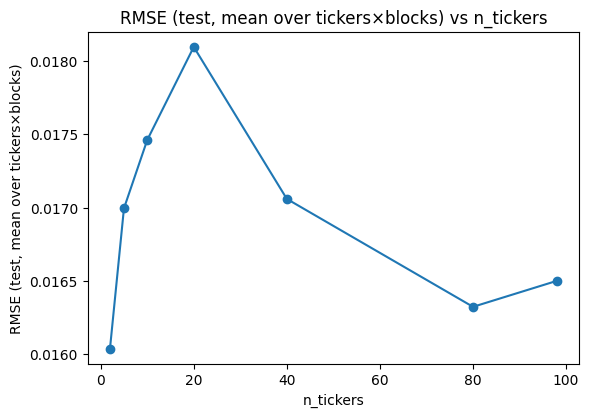

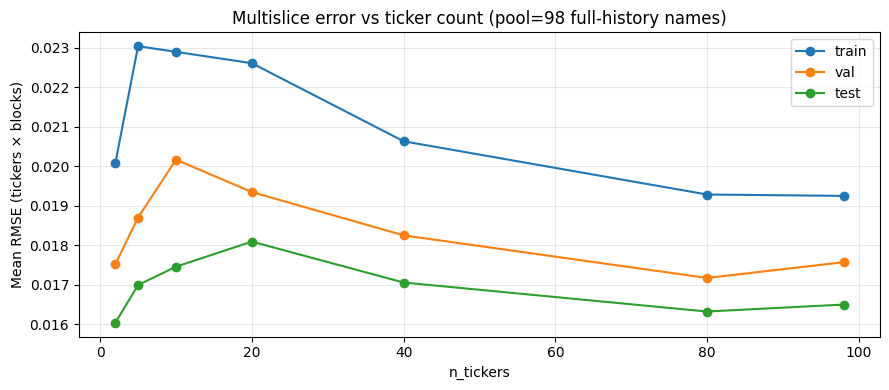

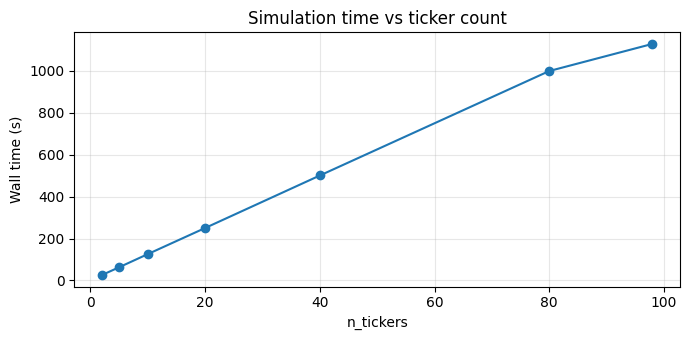

,n_tickers,actual_n_tickers,tickers,rmse_train,rmse_val,rmse_test,rmse_persistence,elapsed_s
0,2,2,"AAPL,ABT",0.020079,0.017520,0.016041,0.023974,25.852780
1,5,5,"AAPL,ABT,ADBE,AIG,ALL",0.023042,0.018705,0.016995,0.025917,62.919500
2,10,10,"AAPL,ABT,ADBE,AIG,ALL,AMGN,AMT,AMZN,AXP,BA",0.022898,0.020169,0.017460,0.027831,125.731178
3,20,20,"AAPL,ABT,ADBE,AIG,ALL,AMGN,AMT,AMZN,AXP,BA,BAC...",0.022611,0.019349,0.018094,0.026987,250.261369
4,40,40,"AAPL,ABT,ADBE,AIG,ALL,AMGN,AMT,AMZN,AXP,BA,BAC...",0.020635,0.018253,0.017059,0.025498,500.695011
5,80,80,"AAPL,ABT,ADBE,AIG,ALL,AMGN,AMT,AMZN,AXP,BA,BAC...",0.019287,0.017175,0.016325,0.024152,999.093738
6,98,98,"AAPL,ABT,ADBE,AIG,ALL,AMGN,AMT,AMZN,AXP,BA,BAC...",0.019252,0.017574,0.016501,0.024689,1128.547807


In [ ]:
sweep_spec = {"n_tickers": N_TICKERS_SWEEP}
Display.plot_sweep_heatmaps(
    ticker_out["results"],
    sweep_spec,
    metric_label="RMSE (test, mean over tickers×blocks)",
    save_as=figpath(15, "ticker_sweep_test_rmse_vs_n_tickers"),
)

ticker_details = pd.DataFrame(ticker_out["details"])
fig, ax = plt.subplots(figsize=(9, 4))
for col, label in [("rmse_train", "train"), ("rmse_val", "val"), ("rmse_test", "test")]:
    ax.plot(ticker_details["n_tickers"], ticker_details[col], "o-", label=label)
ax.set_xlabel("n_tickers")
ax.set_ylabel("Mean RMSE (tickers × blocks)")
ax.set_title(f"Multislice error vs ticker count (pool={ticker_out['n_pool']} full-history names)")
#ax.set_ylim(0.025,0.105)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, 16, "ticker_sweep_rmse_phases")
plt.show()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(ticker_details["n_tickers"], ticker_details["elapsed_s"], "o-")
ax.set_xlabel("n_tickers")
ax.set_ylabel("Wall time (s)")
ax.set_title("Simulation time vs ticker count")
ax.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, 17, "ticker_sweep_elapsed_time")
plt.show()
display(ticker_details)


## 8b. Block-count sweep

How does mean test error change when the same calendar timeline is split into more or fewer walk-forward blocks? Utils.block_sweep() scales trnpat, vanpat, and tenpat together (fixed phase ratios) so that n_blocks × block_step ≈ calendar_span. When warmup_pat > 0, very large n_blocks values may be skipped because each scaled phase must stay longer than warmup_pat + offs.





In [ ]:
#I will rebuild this test of block-length/number at some point. For now we skip it.

## 9. Predictability of the daily-return channel (the decode target)

In this feature set the network's decode target is the **daily return** (`feats[:, 2]`, today/yesterday),
and the secondary channel is a **trailing, direction-agnostic return variance** (`feats[:, 3]`) — i.e. the
model's own running summary of exactly the volatility studied here. A side-question the RBF encoding lets us
answer directly: **how predictable is the daily return one step ahead?**

The intuition to test (after Martin's earlier analysis): large moves should predict large moves the next
day (**volatility clustering**), while the *sign* of the move need not carry over on a daily timescale —
which motivates a dedicated variance side channel for predictable magnitude, separate from the signed
return decode target.

To test this we re-encode the return at high resolution (**100 bins**) and build a lag-1 *transition
correlogram* — the conditional probability of tomorrow's active bin given today's active bin,
P(bin_{t+1} = j | bin_t = i).

To make the question comparable across tickers, each ticker's return is **mean-centred and z-scored** by
its own standard deviation and clipped to ±4σ, so the **centre bin ≈ "flat day" (return ≈ mean ≈ 1.0)**
and extreme bins are large up/down moves. We generate a few views:

- the raw conditional probability P(next | today), and
- the **lift** P(next | today) / P(next) (log2): values > 0 mean a transition is *more* likely than if
  consecutive days were independent.

  - **Magnitude:** mass shifts away from the central cross toward the high-|σ| bins on *both* axes ⇒ big
  moves follow big moves. Quantified by the lag-1 autocorrelation of |Δ| (this is what the col-3 variance
  channel encodes for the network).
- **Direction:** *where* that off-centre mass sits tells us about sign. The **main-diagonal** corners
  (+,+ and −,−) mean the sign is preserved; the **anti-diagonal** corners (+,− and −,+) mean it
  reverses; brightening in all four corners would mean the sign is irrelevant (the "no memory" case, with
  P(same sign) ≈ 0.5).

We check one ticker (AAPL) first, then pool the statistic over every ticker. On this dataset the daily-return
channel is clearly **volatility-persistent** — the lag-1 autocorrelation of |Δ| is positive for ~100% of
tickers (pooled mean ≈ 0.27), so the lift mass spreads out along *both* axes toward the high-σ bins (big
moves follow big moves). The **direction**, by contrast, carries essentially no daily memory: P(same sign
after a large move) ≈ 0.48, i.e. right at chance (only a whisker of mean-reversion). This is the empirical
justification for the feature design: the *magnitude* of returns clusters and is worth feeding back as a
dedicated channel (the col-3 variance feature), while the *signed* return — the thing we actually decode —
is genuinely hard to predict one step ahead, so a fine `return_nbin` is paired with only a coarse
`variance_nbin`.

'figs/SP100/multislice_return_variance/19_return_persistence_AAPL.png'

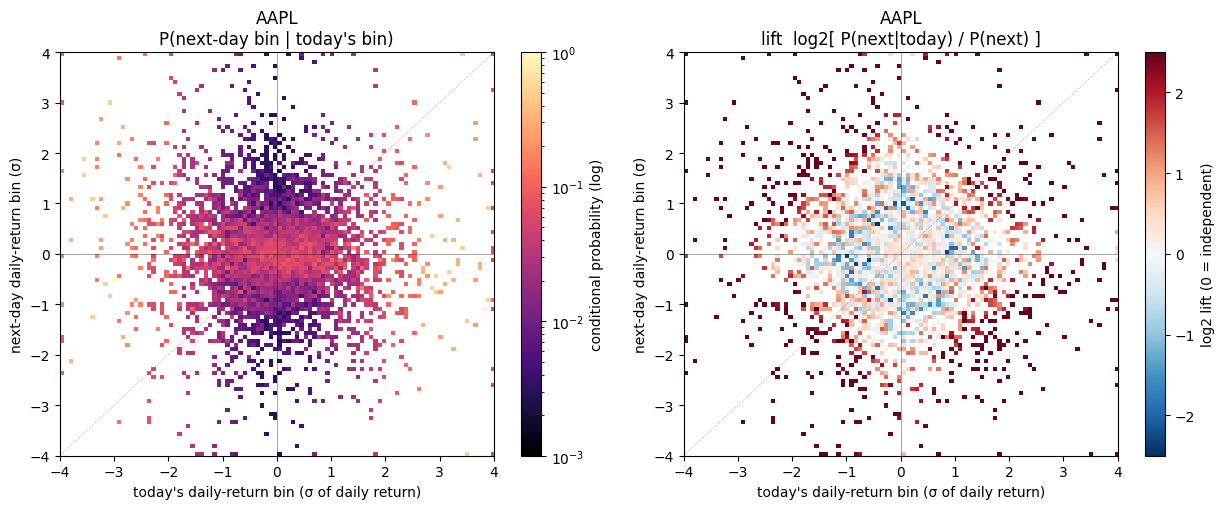

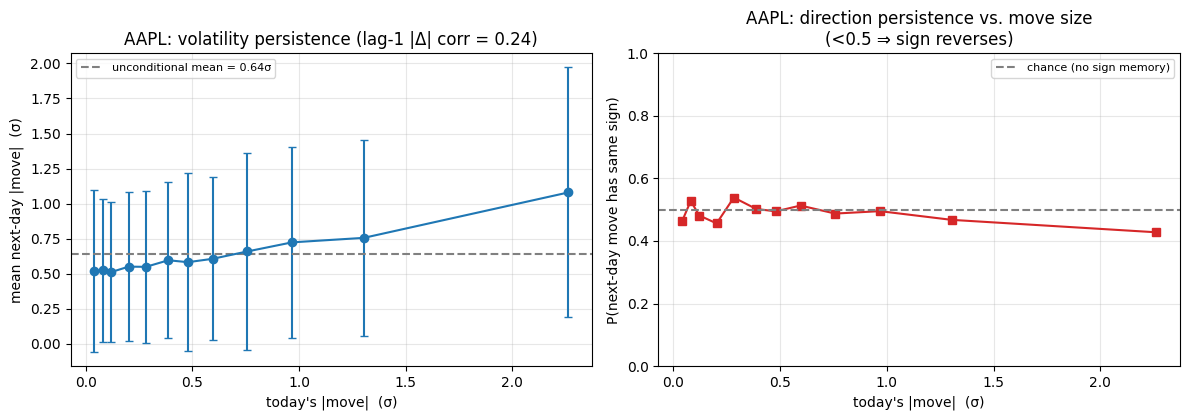

In [ ]:
#New Analysis: high-resolution lag-1 transition correlogram of the daily-return channel
#
# Encode col 2 (daily return, the decode target) into 100 bins and ask: given today's active
# bin, what is the distribution over tomorrow's active bin?  Returns are mean-centred and
# z-scored per ticker (units of that ticker's daily-return sigma, clipped to +/-LIM) so the
# centre bin ~= "flat day" (return ~= 1.0) and the analysis is comparable across tickers.
import importlib
from matplotlib.colors import LogNorm
for m in (FG, RBFBinner):
    importlib.reload(m)

DERIV_NBIN = 100                       # high-resolution bins for the daily return
LIM = 4.0                              # clip range, in standard deviations of daily return
deriv_centers = np.linspace(-LIM, LIM, DERIV_NBIN)
deriv_enc = RBFBinner.Encoder1D(-LIM, LIM, DERIV_NBIN, 2.0 * LIM / DERIV_NBIN)

# Per-ticker features are built in section 2; reload if this cell is run standalone.
if "per_ticker" not in globals():
    per_ticker, csv_lens = FG.load_tickers_features(
        DATA_CSV, ",".join(TICKERS), feature_func=CFG.func, feature_align=W)


def active_deriv_bins(sym):
    """Active high-res return bins for one ticker (mean-centred z-score), or None if degenerate.

    Named ``*_deriv_*`` for continuity with the sibling demo, but here it encodes the daily
    return channel (PRIMARY_COL = col 2)."""
    r = np.asarray(per_ticker[sym]["feats"][:, PRIMARY_COL], dtype=float)
    r = r[np.isfinite(r)]
    sd = r.std()
    if r.size < 50 or sd == 0:
        return None
    z = np.clip((r - r.mean()) / sd, -LIM, LIM)
    return deriv_enc.encode(z).argmax(axis=1)


def transition_counts(bins, n_bins=DERIV_NBIN):
    """Lag-1 transition counts C[i, j] = #(bin_t = i -> bin_{t+1} = j)."""
    C = np.zeros((n_bins, n_bins), dtype=float)
    np.add.at(C, (bins[:-1], bins[1:]), 1.0)
    return C


def conditional_and_lift(C):
    """Row-normalised P(next | today) and lift = P(next | today) / P(next)."""
    row = C.sum(axis=1, keepdims=True)
    P = np.divide(C, row, out=np.full_like(C, np.nan), where=row > 0)
    marg = C.sum(axis=0)
    marg = marg / marg.sum()
    with np.errstate(divide="ignore", invalid="ignore"):
        lift = P / marg[None, :]
    return P, lift


def split_pairs(bins):
    """(today_mag, next_mag, today_sign, next_sign) for every lag-1 step (sigma units)."""
    sgn = np.sign(deriv_centers)[bins]
    mag = np.abs(deriv_centers)[bins]
    return mag[:-1], mag[1:], sgn[:-1], sgn[1:]


def persistence_curves(mt, mn, st, sn, nq=12):
    """Bin by today's |move| (quantiles); return mean next-day |move|, its std, and P(same sign)."""
    qs = np.unique(np.quantile(mt, np.linspace(0, 1, nq + 1)))
    which = np.digitize(mt, qs[1:-1])
    x, y, e, psame = [], [], [], []
    for k in range(len(qs) - 1):
        sel = which == k
        if not sel.any():
            continue
        x.append(mt[sel].mean())
        y.append(mn[sel].mean())
        e.append(mn[sel].std())
        psame.append((st[sel] == sn[sel]).mean())
    return map(np.asarray, (x, y, e, psame))


def plot_transition(P, lift, title, fig_no, stem):
    """Side-by-side conditional-probability and log2-lift correlograms (x=today, y=next-day)."""
    extent = [-LIM, LIM, -LIM, LIM]
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))
    im0 = axes[0].imshow(P.T, origin="lower", aspect="auto", extent=extent, cmap="magma",
                         norm=LogNorm(vmin=1e-3, vmax=np.nanmax(P)))
    axes[0].set_title(f"{title}\nP(next-day bin | today's bin)")
    fig.colorbar(im0, ax=axes[0], label="conditional probability (log)")

    log2lift = np.log2(np.where(lift > 0, lift, np.nan))
    im1 = axes[1].imshow(log2lift.T, origin="lower", aspect="auto", extent=extent,
                         cmap="RdBu_r", vmin=-2.5, vmax=2.5)
    axes[1].set_title(f"{title}\nlift  log2[ P(next|today) / P(next) ]")
    fig.colorbar(im1, ax=axes[1], label="log2 lift (0 = independent)")
    for ax in axes:
        ax.axhline(0, color="k", lw=0.6, alpha=0.4)
        ax.axvline(0, color="k", lw=0.6, alpha=0.4)
        ax.plot([-LIM, LIM], [-LIM, LIM], "k:", lw=0.6, alpha=0.4)
        ax.set_xlabel("today's daily-return bin (σ of daily return)")
        ax.set_ylabel("next-day daily-return bin (σ)")
    plt.tight_layout()
    save_fig(fig, fig_no, stem)
    return fig


# ---- Single-ticker example: AAPL ----
sym = "AAPL"
bins_sym = active_deriv_bins(sym)
C_sym = transition_counts(bins_sym)
P_sym, lift_sym = conditional_and_lift(C_sym)
plot_transition(P_sym, lift_sym, sym, 18, f"return_transition_{sym}")

mt, mn, st, sn = split_pairs(bins_sym)
x, y, e, psame = persistence_curves(mt, mn, st, sn)
base = mn.mean()                                   # unconditional mean next-day |move|
r_vol = np.corrcoef(mt, mn)[0, 1]                  # lag-1 volatility autocorrelation

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].errorbar(x, y, yerr=e, fmt="o-", capsize=3, color="C0")
axes[0].axhline(base, ls="--", color="grey", label=f"unconditional mean = {base:.2f}σ")
axes[0].set_xlabel("today's |move|  (σ)")
axes[0].set_ylabel("mean next-day |move|  (σ)")
axes[0].set_title(f"{sym}: volatility persistence (lag-1 |Δ| corr = {r_vol:.2f})")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(x, psame, "s-", color="C3")
axes[1].axhline(0.5, ls="--", color="grey", label="chance (no sign memory)")
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("today's |move|  (σ)")
axes[1].set_ylabel("P(next-day move has same sign)")
axes[1].set_title(f"{sym}: direction persistence vs. move size\n(<0.5 ⇒ sign reverses)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, 19, f"return_persistence_{sym}")

Pooled 98 tickers, 582,957 lag-1 transitions
Volatility autocorrelation: mean=0.265, 100% of tickers positive
Sign persistence after large move: mean=0.482 (0.5 = no daily-scale directional memory)


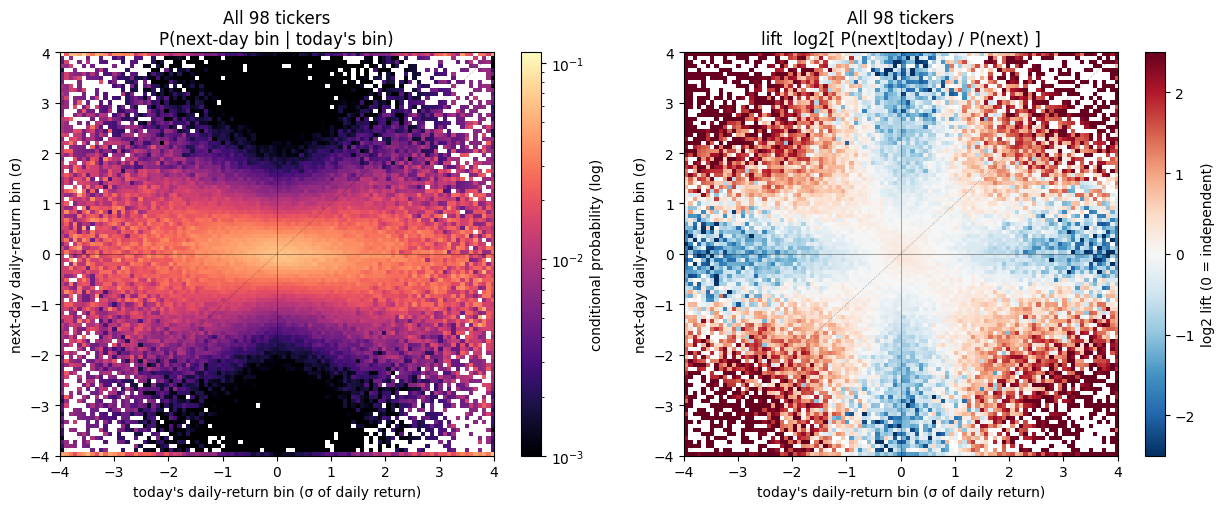

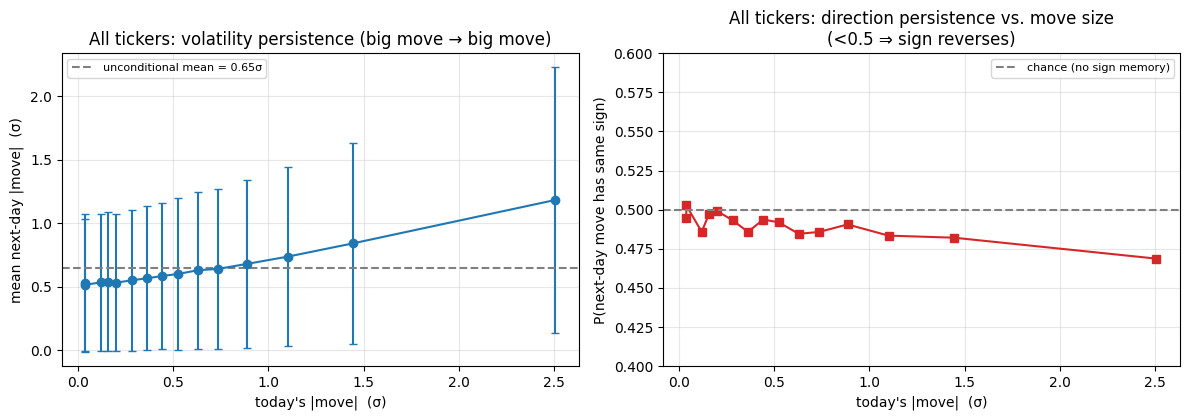

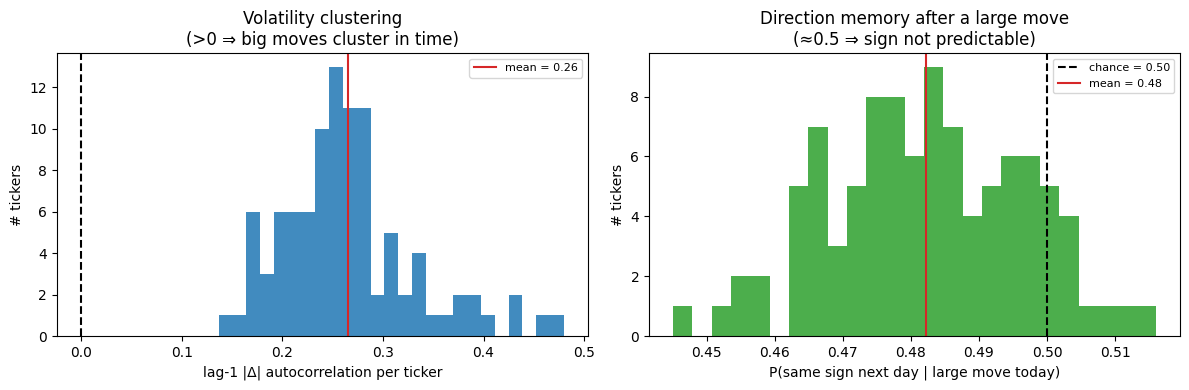

In [ ]:
# Pool the same statistics over every ticker (transitions never cross ticker boundaries).
C_all = np.zeros((DERIV_NBIN, DERIV_NBIN))
mt_all, mn_all, st_all, sn_all = [], [], [], []
vol_autocorr, sign_big = [], []
used = []
for s in per_ticker:
    bins = active_deriv_bins(s)
    if bins is None:
        continue
    C_all += transition_counts(bins)
    a, b, c, d = split_pairs(bins)
    mt_all.append(a); mn_all.append(b); st_all.append(c); sn_all.append(d)
    if a.std() > 0 and b.std() > 0:
        vol_autocorr.append(np.corrcoef(a, b)[0, 1])      # lag-1 volatility clustering
    thr = np.quantile(a, 2 / 3)                            # "large" move = top tercile for this ticker
    big = a >= thr
    if big.any():
        sign_big.append((c[big] == d[big]).mean())         # sign carry-over after a large move
    used.append(s)

mt_all = np.concatenate(mt_all); mn_all = np.concatenate(mn_all)
st_all = np.concatenate(st_all); sn_all = np.concatenate(sn_all)
vol_autocorr = np.asarray(vol_autocorr); sign_big = np.asarray(sign_big)
P_all, lift_all = conditional_and_lift(C_all)
print(f"Pooled {len(used)} tickers, {mt_all.size:,} lag-1 transitions")

# Aggregate transition / lift correlogram across all tickers
plot_transition(P_all, lift_all, f"All {len(used)} tickers", 20, "return_transition_all")

# Aggregate persistence curves
x, y, e, psame = persistence_curves(mt_all, mn_all, st_all, sn_all, nq=15)
base = mn_all.mean()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].errorbar(x, y, yerr=e, fmt="o-", capsize=3, color="C0")
axes[0].axhline(base, ls="--", color="grey", label=f"unconditional mean = {base:.2f}σ")
axes[0].set_xlabel("today's |move|  (σ)")
axes[0].set_ylabel("mean next-day |move|  (σ)")
axes[0].set_title("All tickers: volatility persistence (big move → big move)")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(x, psame, "s-", color="C3")
axes[1].axhline(0.5, ls="--", color="grey", label="chance (no sign memory)")
axes[1].set_ylim(.4, .6)
axes[1].set_xlabel("today's |move|  (σ)")
axes[1].set_ylabel("P(next-day move has same sign)")
axes[1].set_title("All tickers: direction persistence vs. move size\n(<0.5 ⇒ sign reverses)")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, 21, "return_persistence_all")

# Per-ticker summary: does the intuition hold for (almost) every name?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(vol_autocorr, bins=25, color="C0", alpha=0.85)
axes[0].axvline(0, ls="--", color="k")
axes[0].axvline(vol_autocorr.mean(), ls="-", color="C3",
                label=f"mean = {vol_autocorr.mean():.2f}")
axes[0].set_xlabel("lag-1 |Δ| autocorrelation per ticker")
axes[0].set_ylabel("# tickers")
axes[0].set_title("Volatility clustering\n(>0 ⇒ big moves cluster in time)")
axes[0].legend(fontsize=8)

axes[1].hist(sign_big, bins=25, color="C2", alpha=0.85)
axes[1].axvline(0.5, ls="--", color="k", label="chance = 0.50")
axes[1].axvline(sign_big.mean(), ls="-", color="C3",
                label=f"mean = {sign_big.mean():.2f}")
axes[1].set_xlabel("P(same sign next day | large move today)")
axes[1].set_ylabel("# tickers")
axes[1].set_title("Direction memory after a large move\n(≈0.5 ⇒ sign not predictable)")
axes[1].legend(fontsize=8)
plt.tight_layout()
save_fig(fig, 22, "return_persistence_summary")

print(f"Volatility autocorrelation: mean={vol_autocorr.mean():.3f}, "
      f"{100 * (vol_autocorr > 0).mean():.0f}% of tickers positive")
print(f"Sign persistence after large move: mean={sign_big.mean():.3f} "
      f"(0.5 = no daily-scale directional memory)")

In [5]:
# First big evo search over midsummer (should finish Monday 8:00am)
"""
python3 evolve_hyperparams_v3.py \
    --time 259200 \
    --base Parameters_multislice_return_variance.par \
    --work-par Parameters_multislice_return_variance_ea_work.par \
    --K 2 30 \
    --K_mode linear logarithmic \
    --return_nbin 2 80 \
    --variance_nbin 2 20 \
    --variance_window 2 20 \
    --binmode rbf rbf-quantile \
    --taumax 10 1000 \
    --pop 12 \
    --history ea_return_variance_trace.jsonl \
    --out-json ea_return_variance_best.json
"""

'\npython3 evolve_hyperparams_v3.py     --time 259200     --base Parameters_multislice_return_variance.par     --work-par Parameters_multislice_return_variance_ea_work.par     --K 2 30     --K_mode linear logarithmic     --return_nbin 2 80     --variance_nbin 2 20     --variance_window 2 20     --binmode rbf rbf-quantile     --taumax 10 1000     --pop 12     --history ea_return_variance_trace.jsonl     --out-json ea_return_variance_best.json\n'

## 10. Evolutionary search post-mortem (7-D parameter space)

The 72-hour run driven by `evolve_hyperparams_v3.py` logged every evaluation to
`ea_return_variance_trace.jsonl`. Below we load that trace and inspect:

1. **Search trajectory** — how validation RMSE improved over wall time and generations.
2. **Near-optimal manifold** — where the 0.5%-of-best evaluations live in parameter space.
3. **Cluster structure** — PCA + *k*-means on encoded parameters to see whether several
   distinct good configurations emerged (e.g. high vs low `return_nbin`, `rbf` vs `rbf-quantile`).

Trace: 1341 evaluations (635 unique genotypes) over 134 generations
Wall time: 72.0 h   objective: rmse_validation
Best validation RMSE: 0.017703  (gen 36, t=49.9 h)
Near-optimal (≤0.5% above best): 1180 evals, 522 unique genotypes
New-best events: 30
  (all near-optimal genotypes share binmode=rbf-quantile)

Best genotype (ea_return_variance_best.json):
  K                = 14
  K_mode           = linear
  return_nbin      = 4
  variance_nbin    = 20
  variance_window  = 19
  binmode          = rbf-quantile
  taumax           = 1000.0


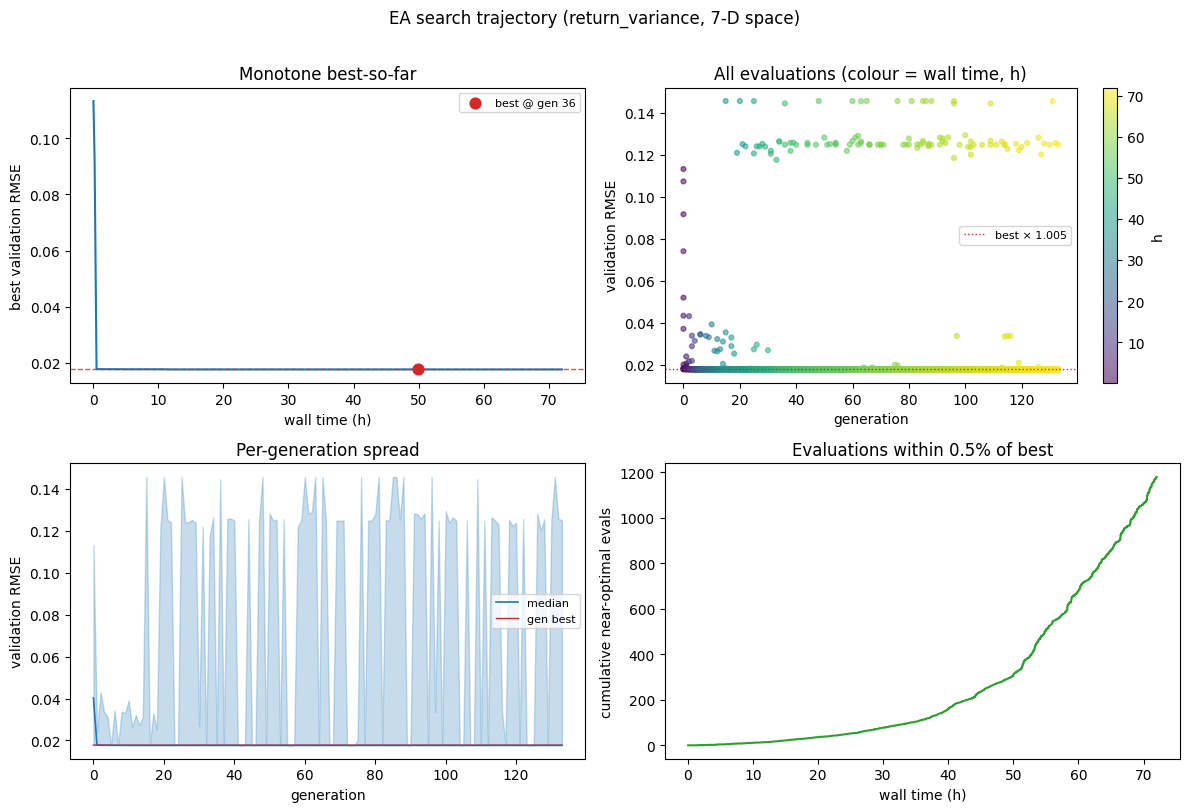

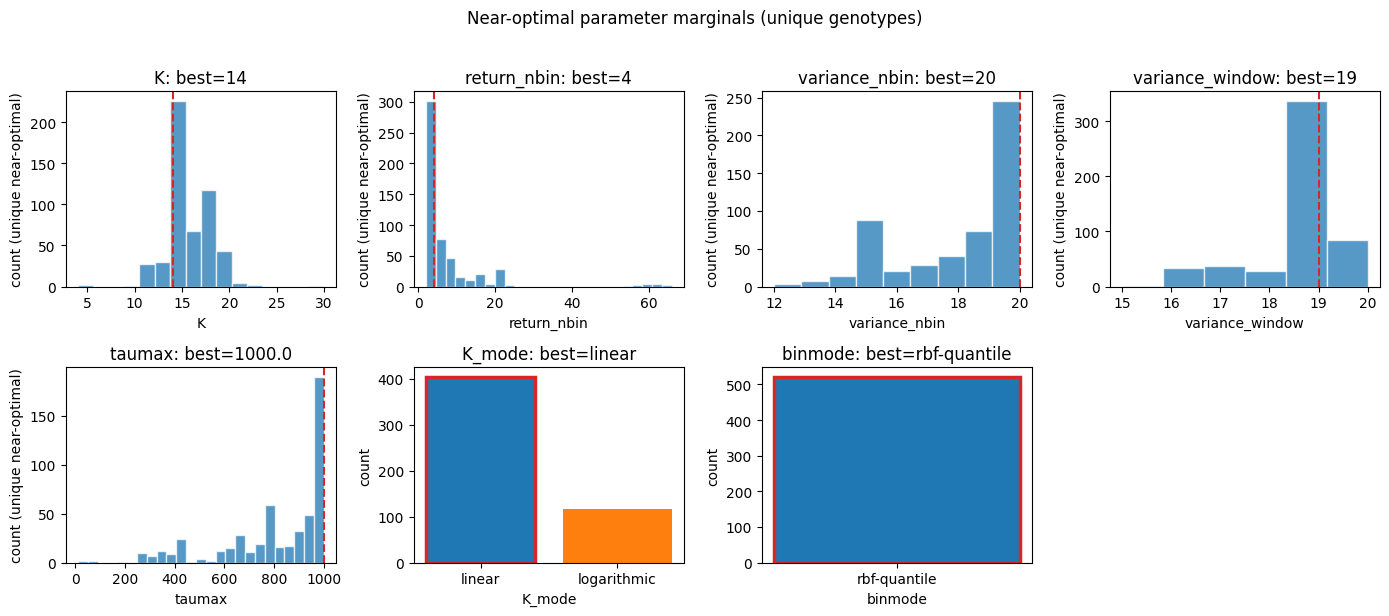

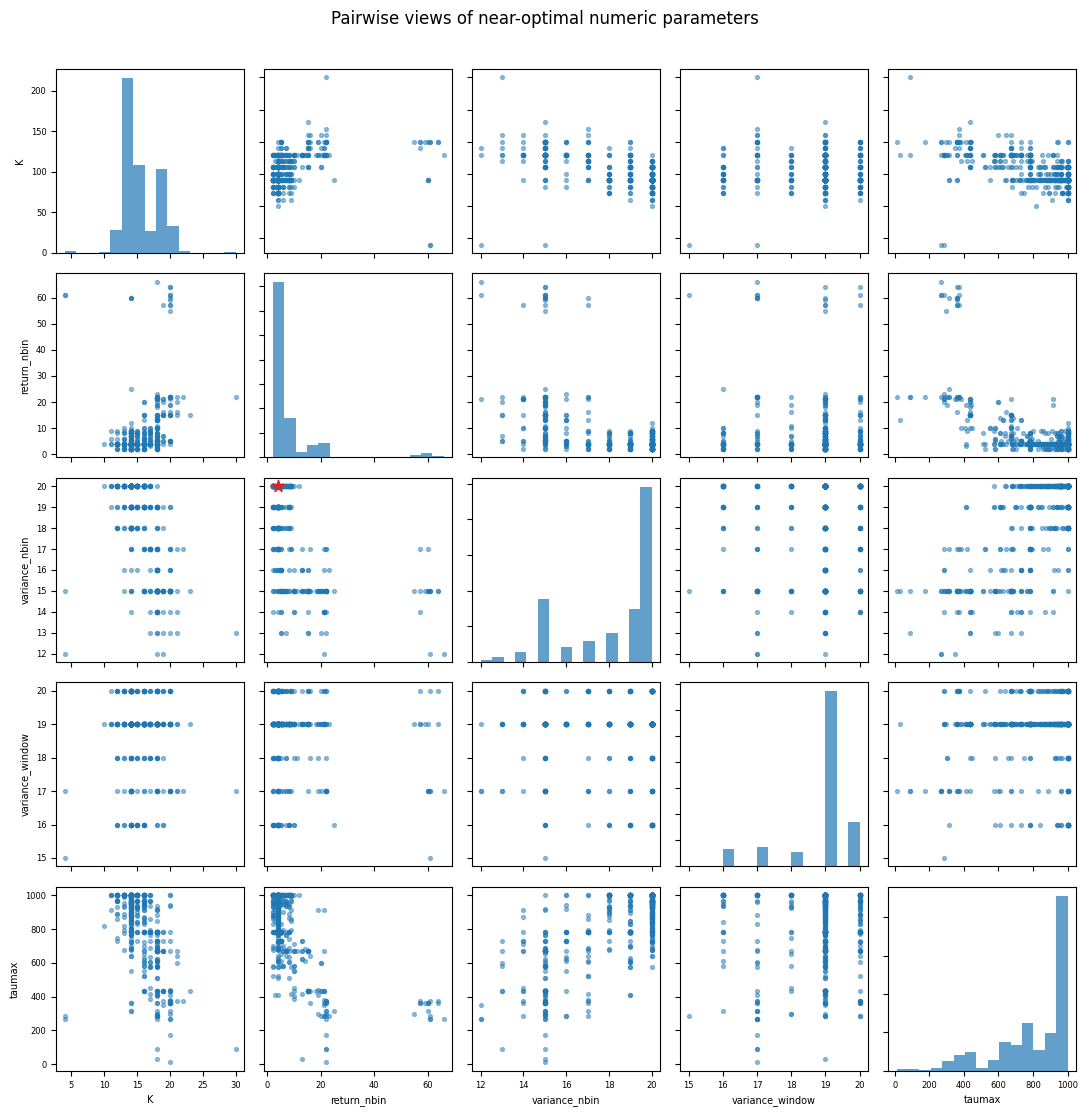

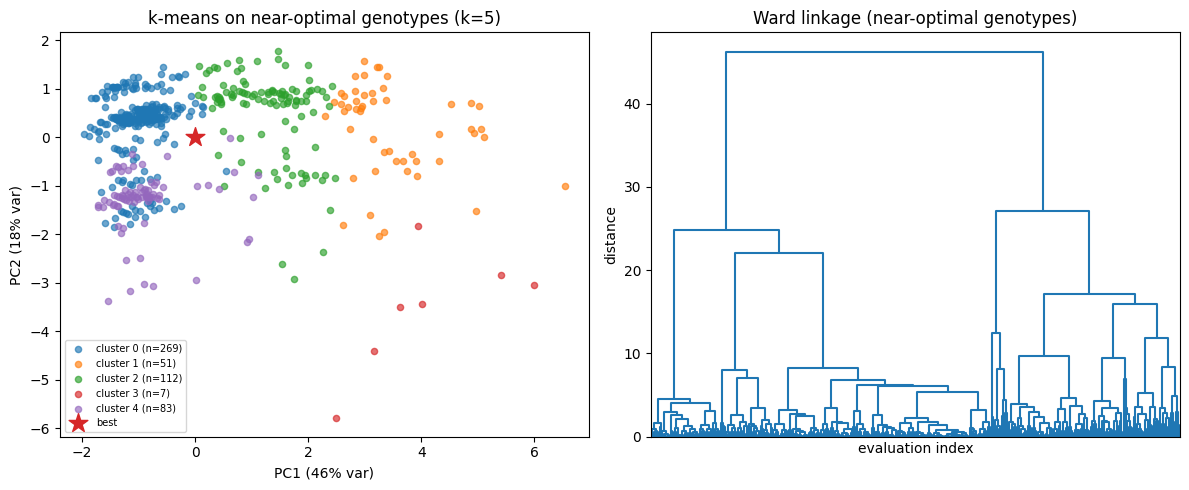


K-means clusters (k=5, near-optimal unique genotypes):

--- cluster 0  (n=269, fitness median=0.017704) ---
  K                 median=1e+01  IQR=[1e+01, 2e+01]
  K_mode            {'linear': 269}
  return_nbin       median=4  IQR=[4, 4]
  variance_nbin     median=2e+01  IQR=[2e+01, 2e+01]
  variance_window   median=2e+01  IQR=[2e+01, 2e+01]
  binmode           {'rbf-quantile': 269}
  taumax            median=1e+03  IQR=[9e+02, 1e+03]
--- cluster 1  (n=51, fitness median=0.017713) ---
  K                 median=2e+01  IQR=[2e+01, 2e+01]
  K_mode            {'linear': 43, 'logarithmic': 8}
  return_nbin       median=2e+01  IQR=[2e+01, 2e+01]
  variance_nbin     median=2e+01  IQR=[2e+01, 2e+01]
  variance_window   median=2e+01  IQR=[2e+01, 2e+01]
  binmode           {'rbf-quantile': 51}
  taumax            median=4e+02  IQR=[3e+02, 4e+02]
--- cluster 2  (n=112, fitness median=0.017706) ---
  K                 median=2e+01  IQR=[2e+01, 2e+01]
  K_mode            {'linear': 92, 'logarithm

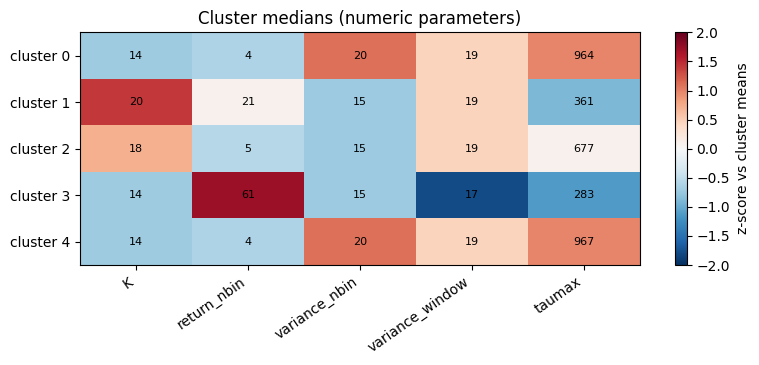

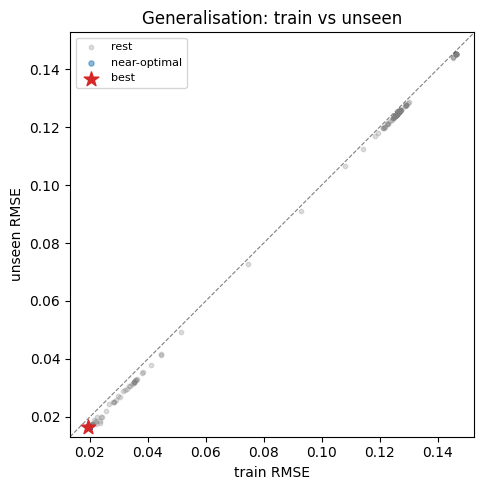


Parameter summary (numeric medians / categorical modes):


,K,K_mode,return_nbin,variance_nbin,variance_window,binmode,taumax
all,14.0,linear,4.0,20.0,19.0,rbf-quantile,1000.0
near_optimal,15.0,linear,4.0,19.0,19.0,rbf-quantile,891.677088
best,14,linear,4,20,19,rbf-quantile,1000.0


In [15]:
# --- EA trace analysis: trajectory, near-optimal region, clustering -----------------
import json
from pathlib import Path

from scipy.cluster.vq import kmeans2
from scipy.cluster.hierarchy import linkage, dendrogram

TRACE_PATH = "ea_return_variance_trace.jsonl"
BEST_PATH = "ea_return_variance_best.json"

PARAM_COLS = [
    "K", "K_mode", "return_nbin", "variance_nbin",
    "variance_window", "binmode", "taumax",
]
NUM_COLS = ["K", "return_nbin", "variance_nbin", "variance_window", "taumax"]
CAT_COLS = ["K_mode", "binmode"]
METRIC_COLS = ["rmse_train", "rmse_validation", "rmse_unseen", "rmse_persistence"]


def _load_jsonl(path):
    rows = [json.loads(line) for line in Path(path).read_text().splitlines() if line.strip()]
    return pd.DataFrame(rows)


def _encode_params(df):
    """Numeric + one-hot encoding for clustering / PCA."""
    out = df[NUM_COLS].astype(float).copy()
    out["K_mode_linear"] = (df["K_mode"] == "linear").astype(float)
    out["binmode_rbf"] = (df["binmode"] == "rbf").astype(float)
    return out


def _standardize(X):
    X = np.asarray(X, float)
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    sigma[sigma < 1e-12] = 1.0
    return (X - mu) / sigma, mu, sigma


def _pca_fit_transform(X):
    Xs, mu, sigma = _standardize(X)
    Xc = Xs - Xs.mean(axis=0)
    _, s, vt = np.linalg.svd(Xc, full_matrices=False)
    comps = vt[:2]
    coords = Xc @ comps.T
    var_exp = (s[:2] ** 2) / max((s ** 2).sum(), 1e-12) * 100
    return coords, mu, sigma, comps, var_exp


def _pca_transform(X, mu, sigma, comps):
    return ((np.asarray(X, float) - mu) / sigma - ((np.asarray(X, float) - mu) / sigma).mean(axis=0)) @ comps.T


def _dedupe_best(df, key_cols=PARAM_COLS):
    return (
        df.sort_values("fitness")
        .drop_duplicates(subset=key_cols, keep="first")
        .reset_index(drop=True)
    )


def _pick_kmeans_k(X, k_min=2, k_max=6, seed=0):
    """Pick k by minimum total within-cluster SS (on whitened features)."""
    rng = np.random.default_rng(seed)
    best_k, best_inertia = k_min, np.inf
    for k in range(k_min, k_max + 1):
        _, labels = kmeans2(
            X, k, minit="++", iter=50, seed=rng.integers(0, 2**31 - 1)
        )
        inertia = sum(
            ((X[labels == j] - X[labels == j].mean(axis=0)) ** 2).sum()
            for j in range(k)
            if (labels == j).any()
        )
        if inertia < best_inertia:
            best_inertia, best_k = inertia, k
    return best_k


# --- load -----------------------------------------------------------------------
ea = _load_jsonl(TRACE_PATH)
best_rec = json.loads(Path(BEST_PATH).read_text())
best_fit = float(best_rec["fitness"])
near_eps = 1.005  # within 0.5 % of best validation RMSE
near = ea[ea["fitness"] <= best_fit * near_eps].copy()
near_u = _dedupe_best(near)

n_gens = int(ea["gen"].max()) + 1
n_evals = len(ea)
n_unique = _dedupe_best(ea).shape[0]
wall_h = ea["t"].max() / 3600.0
best_row = ea.loc[ea["fitness"].idxmin()]
improve_gens = ea.index[ea["best_fitness"].diff() < -1e-9]

print(f"Trace: {n_evals} evaluations ({n_unique} unique genotypes) over {n_gens} generations")
print(f"Wall time: {wall_h:.1f} h   objective: {best_rec['objective']}")
print(f"Best validation RMSE: {best_fit:.6f}  (gen {int(best_row['gen'])}, t={best_row['t']/3600:.1f} h)")
print(f"Near-optimal (≤{100*(near_eps-1):.1f}% above best): {len(near)} evals, {len(near_u)} unique genotypes")
print(f"New-best events: {len(improve_gens)}")
for col in CAT_COLS:
    modes = near_u[col].value_counts()
    if len(modes) == 1:
        print(f"  (all near-optimal genotypes share {col}={modes.index[0]})")
print("\nBest genotype (ea_return_variance_best.json):")
for c in PARAM_COLS:
    print(f"  {c:16s} = {best_rec[c]}")

# --- 1. Search trajectory -------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# (a) best-so-far vs wall time
ax = axes[0, 0]
ax.plot(ea["t"] / 3600, ea["best_fitness"], color="C0", lw=1.5)
ax.axhline(best_fit, color="C3", ls="--", lw=1, alpha=0.8)
ax.scatter(
    best_row["t"] / 3600, best_fit, color="C3", s=60, zorder=5,
    label=f"best @ gen {int(best_row['gen'])}",
)
ax.set_xlabel("wall time (h)")
ax.set_ylabel("best validation RMSE")
ax.set_title("Monotone best-so-far")
ax.legend(fontsize=8)

# (b) per-evaluation fitness vs generation
ax = axes[0, 1]
sc = ax.scatter(
    ea["gen"], ea["fitness"], c=ea["t"] / 3600, s=12, alpha=0.55, cmap="viridis"
)
ax.axhline(best_fit * near_eps, color="C3", ls=":", lw=1, label=f"best × {near_eps}")
ax.set_xlabel("generation")
ax.set_ylabel("validation RMSE")
ax.set_title("All evaluations (colour = wall time, h)")
fig.colorbar(sc, ax=ax, label="h")
ax.legend(fontsize=8)

# (c) generation-wise distribution
ax = axes[1, 0]
gen_stats = ea.groupby("gen")["fitness"].agg(["min", "median", "max"])
ax.fill_between(gen_stats.index, gen_stats["min"], gen_stats["max"], alpha=0.25, color="C0")
ax.plot(gen_stats.index, gen_stats["median"], color="C0", lw=1.2, label="median")
ax.plot(gen_stats.index, gen_stats["min"], color="C3", lw=1.0, label="gen best")
ax.set_xlabel("generation")
ax.set_ylabel("validation RMSE")
ax.set_title("Per-generation spread")
ax.legend(fontsize=8)

# (d) cumulative near-optimal count
ax = axes[1, 1]
cum_near = (ea["fitness"] <= best_fit * near_eps).cumsum()
ax.plot(ea["t"] / 3600, cum_near, color="C2", lw=1.5)
ax.set_xlabel("wall time (h)")
ax.set_ylabel("cumulative near-optimal evals")
ax.set_title(f"Evaluations within {100*(near_eps-1):.1f}% of best")

fig.suptitle("EA search trajectory (return_variance, 7-D space)", y=1.01, fontsize=12)
fig.tight_layout()
save_fig(fig, 23, "ea_trajectory")
plt.show()

# --- 2. Near-optimal parameter marginals ----------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.ravel()

for i, col in enumerate(NUM_COLS):
    ax = axes[i]
    ax.hist(near_u[col], bins=min(25, near_u[col].nunique()), color="C0", alpha=0.75, edgecolor="white")
    ax.axvline(best_rec[col], color="C3", ls="--", lw=1.5)
    ax.set_xlabel(col)
    ax.set_ylabel("count (unique near-optimal)")
    ax.set_title(f"{col}: best={best_rec[col]}")

for j, col in enumerate(CAT_COLS):
    ax = axes[len(NUM_COLS) + j]
    counts = near_u[col].value_counts()
    bars = ax.bar(counts.index.astype(str), counts.values, color=["C0", "C1"][: len(counts)])
    ax.axhline(0, color="k", lw=0.5)
    ax.set_xlabel(col)
    ax.set_ylabel("count")
    best_val = str(best_rec[col])
    for b, lab in zip(bars, counts.index.astype(str)):
        if lab == best_val:
            b.set_edgecolor("C3")
            b.set_linewidth(2.5)
    ax.set_title(f"{col}: best={best_val}")

axes[-1].axis("off")
fig.suptitle("Near-optimal parameter marginals (unique genotypes)", y=1.02, fontsize=12)
fig.tight_layout()
save_fig(fig, 24, "ea_near_optimal_marginals")
plt.show()

# --- 3. Pairwise numeric scatter (near-optimal) -----------------------------------
pair_cols = NUM_COLS
n_p = len(pair_cols)
fig, axes = plt.subplots(n_p, n_p, figsize=(2.2 * n_p, 2.2 * n_p))
for r, ycol in enumerate(pair_cols):
    for c, xcol in enumerate(pair_cols):
        ax = axes[r, c]
        if r == c:
            ax.hist(near_u[xcol], bins=15, color="C0", alpha=0.7)
        else:
            ax.scatter(near_u[xcol], near_u[ycol], s=8, alpha=0.45, c="C0")
            if xcol == "return_nbin" and ycol == "variance_nbin":
                ax.scatter(
                    best_rec["return_nbin"], best_rec["variance_nbin"],
                    c="C3", s=80, marker="*", zorder=5,
                )
        if r == n_p - 1:
            ax.set_xlabel(xcol, fontsize=7)
        else:
            ax.set_xticklabels([])
        if c == 0:
            ax.set_ylabel(ycol, fontsize=7)
        else:
            ax.set_yticklabels([])
        ax.tick_params(labelsize=6)
fig.suptitle("Pairwise views of near-optimal numeric parameters", y=1.01, fontsize=12)
fig.tight_layout()
save_fig(fig, 25, "ea_near_optimal_pairs")
plt.show()

# --- 4. PCA embedding + clustering ----------------------------------------------
X_raw = _encode_params(near_u).values
X_w, _, _ = _standardize(X_raw)
coords, pca_mu, pca_sigma, pca_comps, var_exp = _pca_fit_transform(X_raw)
best_xy = _pca_transform(_encode_params(pd.DataFrame([best_rec])).values, pca_mu, pca_sigma, pca_comps)

k = _pick_kmeans_k(X_w, k_min=2, k_max=5)
_, labels = kmeans2(X_w, k, minit="++", iter=80, seed=42)
near_u = near_u.copy()
near_u["cluster"] = labels

Z = linkage(X_w, method="ward")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
for cl in range(k):
    m = labels == cl
    ax.scatter(
        coords[m, 0], coords[m, 1], s=20, alpha=0.65, label=f"cluster {cl} (n={m.sum()})"
    )
ax.scatter(best_xy[0, 0], best_xy[0, 1], c="C3", marker="*", s=200, zorder=10, label="best")
ax.set_xlabel(f"PC1 ({var_exp[0]:.0f}% var)")
ax.set_ylabel(f"PC2 ({var_exp[1]:.0f}% var)")
ax.set_title(f"k-means on near-optimal genotypes (k={k})")
ax.legend(fontsize=7, loc="best")

ax = axes[1]
dendrogram(Z, ax=ax, no_labels=True, color_threshold=0)
ax.set_title("Ward linkage (near-optimal genotypes)")
ax.set_xlabel("evaluation index")
ax.set_ylabel("distance")

fig.tight_layout()
save_fig(fig, 26, "ea_cluster_pca")
plt.show()

# cluster profiles
print(f"\nK-means clusters (k={k}, near-optimal unique genotypes):\n")
profile_rows = []
for cl in range(k):
    sub = near_u[near_u["cluster"] == cl]
    row = {"cluster": cl, "n": len(sub), "fitness_median": sub["fitness"].median()}
    for col in NUM_COLS:
        row[f"{col}_median"] = sub[col].median()
    for col in CAT_COLS:
        row[f"{col}_mode"] = sub[col].mode().iloc[0]
    profile_rows.append(row)
    print(f"--- cluster {cl}  (n={len(sub)}, fitness median={sub['fitness'].median():.6f}) ---")
    for col in PARAM_COLS:
        if col in NUM_COLS:
            q = sub[col].quantile([0.25, 0.5, 0.75])
            print(f"  {col:16s}  median={q[0.5]:.1g}  IQR=[{q[0.25]:.1g}, {q[0.75]:.1g}]")
        else:
            print(f"  {col:16s}  {sub[col].value_counts().to_dict()}")

profile_df = pd.DataFrame(profile_rows)

# heatmap-style cluster centroids (numeric, z-scored across clusters)
fig, ax = plt.subplots(figsize=(8, max(2.5, 0.55 * k + 1)))
centroids = near_u.groupby("cluster")[NUM_COLS].median()
centroids_z = centroids.apply(lambda col: (col - col.mean()) / (col.std() + 1e-9))
im = ax.imshow(centroids_z.values, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)
ax.set_xticks(range(len(NUM_COLS)))
ax.set_xticklabels(NUM_COLS, rotation=35, ha="right")
ax.set_yticks(range(k))
ax.set_yticklabels([f"cluster {i}" for i in range(k)])
for r in range(k):
    for c in range(len(NUM_COLS)):
        ax.text(c, r, f"{centroids.iloc[r, c]:.0f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="z-score vs cluster means")
ax.set_title("Cluster medians (numeric parameters)")
fig.tight_layout()
save_fig(fig, 27, "ea_cluster_profiles")
plt.show()

# --- 5. Generalisation gap for near-optimal vs rest -----------------------------
fig, ax = plt.subplots(figsize=(6, 5))
rest = ea[ea["fitness"] > best_fit * near_eps]
ax.scatter(rest["rmse_train"], rest["rmse_unseen"], s=10, alpha=0.25, c="C7", label="rest")
ax.scatter(near["rmse_train"], near["rmse_unseen"], s=14, alpha=0.5, c="C0", label="near-optimal")
ax.scatter(
    best_rec["rmse_train"], best_rec["rmse_unseen"],
    c="C3", s=120, marker="*", zorder=5, label="best",
)
lim = ax.get_xlim()
ax.plot(lim, lim, "k--", lw=0.8, alpha=0.5)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel("train RMSE")
ax.set_ylabel("unseen RMSE")
ax.set_title("Generalisation: train vs unseen")
ax.legend(fontsize=8)
ax.set_aspect("equal")
fig.tight_layout()
save_fig(fig, 28, "ea_generalisation")
plt.show()

# --- summary table --------------------------------------------------------------
def _param_summary(df, cols):
    out = {}
    for c in cols:
        out[c] = df[c].median() if c in NUM_COLS else df[c].mode().iloc[0]
    return out

summary = pd.DataFrame({
    "all": _param_summary(ea, PARAM_COLS),
    "near_optimal": _param_summary(near_u, PARAM_COLS),
    "best": {c: best_rec[c] for c in PARAM_COLS},
}).T
print("\nParameter summary (numeric medians / categorical modes):")
display(summary)

## 11. Takeaways

- **Raw data** live in a wide SP100 CSV; each ticker is max-normalised before feature extraction, and a
  ticker only activates in blocks where its feature history fully covers the window (late-IPO names sit out
  early blocks).

- **Features** (`feature_set return_variance`) compress short-term dynamics into a fixed-length RBF pattern
  per day; the network predicts the **daily-return channel (col 2)** `offs` steps ahead, with a trailing,
  direction-agnostic **return-variance channel (col 3)** as the secondary input.

- **Multislice** walks the shared calendar forward in blocks; the same recurrent network keeps learning
  across blocks *and* tickers without resetting weights. Optional **`warmup_pat`** replays the first patterns
  of each k > 0 ticker segment forward-only so RMSE is scored only on the settled suffix.

- Across the configured ticker list, **test RMSE varies strongly by block** (often peaking in mid-sample
  crisis years) and **by sector** — defensive staples vs. high-beta tech/industrial names separate clearly
  in §5–§6.

- **Stitched walk-forward predictions with uncertainty bands** (§6b) show where the model is confident
  versus where the output distribution widens — more informative than a single RMSE scalar.

- Always compare against the **persistence baseline** (y_{t+offs} ≈ y_t). Focus on cross-ticker /
  cross-block *rankings* and on whether later blocks reduce error for the same ticker.

- **Hyperparameters matter:** §7 1-D sweeps over `K` / `K_mode`, `taumax`, `return_nbin`, `variance_nbin`,
  `variance_window`, and `binmode` (via dedicated `*_work.par`) show which knobs move validation error;
  notably **`return_nbin` has almost flat test RMSE from 2–20** — coarser return bins do not materially
  change scored error. The **ticker-count sweep** (§8) shows how mean error scales as more tickers are
  concatenated; the **block-count sweep** (§8b) is reserved for future work.

- **Feature predictability** (§9): the daily-return decode target is **volatility-persistent**
  (|Δ| autocorrelation ≈ 0.27, positive for ~100% of tickers) but carries **essentially no daily sign
  memory** (P(same sign | large move) ≈ 0.48). Big moves predict big moves; direction is close to a coin
  flip, but has a bias towards reversing on big moves. This motivates a dedicated variance side channel — but the **roles of the two bin counts are not
  symmetric**: `variance_nbin` conditions on predictable magnitude regimes, while `return_nbin` sets the
  RBF grid for the hard-to-forecast signed return.

- **Scoring is not binned:** validation RMSE compares **predicted vs. true daily return ratios**
  (`exp(log_return)`), after soft RBF decode — not bin indices or quantised targets. Low `return_nbin`
  therefore does **not** simplify the metric; it only coarsens the input/output representation.

- **72-hour evolutionary search** (§10, `ea_return_variance_trace.jsonl`): 1,341 evaluations over 7
  parameters; best validation RMSE **0.01770** at gen 36 (~50 h), then a long plateau (~88% of evals
  within 0.5% of best). Best genotype: `K=14`, `K_mode=linear`, `return_nbin=4`, `variance_nbin=20`,
  `variance_window=19`, `binmode=rbf-quantile`, `taumax=1000`. All near-optimal points use
  **`rbf-quantile`**; **`return_nbin` clusters at 2–5** while **`variance_nbin` sits at 15–20** — the
  opposite of the naive “fine return, coarse variance” guess, and consistent with §9: fine volatility context,
  coarse parameterisation of an almost unpredictable signed return. Clusters in the near-optimal set differ
  mainly in `K`, `K_mode`, and `taumax`, not in the variance-channel settings.
